# Data Cleaning and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('SuperMarket Analysis.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


While Inspecting the few rows from the table obove we can proceed with some approaches about how we are going to apply the data cleaning. First of all, we can state that Invoice ID is a unique identifier and can be dropped. cogs is also short for cost of goods sold (unit price * quantity). We can also see that the gross margin percentage is the same for all the rows and should be dropped. Date and time are as strings so we should convert them in a way we could used them if deemed necessary.  

In [2]:
# Keep all columns except Invoice ID and gross margin percentage
df_clean = df.drop(['Invoice ID', 'gross margin percentage'], axis=1)

# Check missing values
print("Missing values:\n", df_clean.isnull().sum())

# Convert Date and Time to useful features
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m/%d/%Y')
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['Hour'] = pd.to_datetime(df_clean['Time'], format='%I:%M:%S %p').dt.hour
df_clean.drop(['Date', 'Time'], axis=1, inplace=True)

# For regression, drop cogs, Tax 5%, gross income to avoid data leakage
df_reg = df_clean.drop(['cogs', 'Tax 5%', 'gross income'], axis=1)

# Define features and target
X = df_reg.drop('Sales', axis=1)
y = df_reg['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Missing values:
 Branch           0
City             0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Tax 5%           0
Sales            0
Date             0
Time             0
Payment          0
cogs             0
gross income     0
Rating           0
dtype: int64
Features shape: (1000, 13)
Target shape: (1000,)


We drop only Invoice ID and gross margin percentage.
But for regression we must drop cogs, Tax 5%, and gross income because Sales is exactly cogs * 1.05. Keeping them would give perfect prediction (data leakage) which would not be a real learning task.  

- **Sales = cogs + Tax 5%**  
From the data: Tax 5% = 0.05 × cogs. Therefore Sales = cogs × 1.05 exactly.  
If we keep cogs or Tax 5% as input features, the regression model would learn this deterministic relationship perfectly. That would give an R² of 1.0 and zero error – which is not a meaningful learning task. It’s essentially a linear transformation, not a prediction problem.  
- **gross income = Sales - cogs = Tax 5%**  
So it’s identical to Tax 5%. Keeping it would be redundant and also cause perfect collinearity.  



# Preprocessing and train/test split  
We standardize numeric features and one‑hot encode categoricals.



In [3]:
numeric_cols = ['Unit price', 'Quantity', 'Rating', 'Month', 'DayOfWeek', 'Day', 'Hour']
categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 800, Test size: 200


# Regression Models and Evaluation Framework

Currently we have:  
- df_clean (after dropping only Invoice ID and gross margin percentage)

- df_reg (after also dropping cogs, Tax 5%, gross income)

- X and y (Sales as target)

- preprocessor (scales numeric, one‑hot encodes categorical)

- X_train, X_test, y_train, y_test already split  

## 1. Linear Regression

Baseline model which assumes linear relationship between features and sales which is good for interpretability.

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train Linear Regression
lr = LinearRegression()
pipe_lr = Pipeline([('pre', preprocessor), ('reg', lr)])
pipe_lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr = pipe_lr.predict(X_test)

# Metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print("=== Linear Regression ===")
print(f"MSE: {mse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"MAPE: {mape_lr:.2f}%")
print(f"R²: {r2_lr:.4f}")

# Data‑specific insight: Which features drive sales?
coef = pipe_lr.named_steps['reg'].coef_
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment'])
feature_names = np.concatenate([numeric_cols, cat_features])
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False).head(10)
print("\nTop 10 most influential features (by absolute coefficient):")
print(coef_df)

=== Linear Regression ===
MSE: 6391.76
MAE: 59.43
MAPE: 62.30%
R²: 0.9018

Top 10 most influential features (by absolute coefficient):
                            Feature  Coefficient
1                          Quantity   171.458538
0                        Unit price   152.737896
18              Payment_Credit card     9.828451
12                      Gender_Male    -8.352166
11             Customer type_Normal     6.894723
16  Product line_Home and lifestyle     6.583736
2                            Rating    -5.045011
14  Product line_Food and beverages     4.773257
15   Product line_Health and beauty    -4.198896
7                      Branch_Cairo    -4.037128



- MSE	6391.76:	Average squared error is large because sales range up to ~1000.    
- MAE	59.43:	On average, predictions are off by about 59.43 monetary units.    
- MAPE 62.30%:	Predictions deviate from actual sales by 62% on average – very high.    
- R²	0.9018:	The model explains 90% of the variance in sales – seemingly excellent.   

But it seems we have a paradox here, while R² is very high which is very good, our MAPE value indicates poor performance. When dealing with models and their results we should look closely at the features we have. In this problem which our target is sale, Sales = Unit Price * Quantity * 1.05 which is a multiplicative relationship. Linear regression assumes **additive** effects. The model tries to approxiamte multiplication by assigning large coesfficients to **Unit Price** and **Quantity** seperately, but without an interaction term which is their multiplication, it fails to capture the product correctly. This leads to large relative errors, especially for transactions where one factor is small and the other large.  
R² measures linear correlation, Since **unit price** and **quantity** are strongly correlated with **Sales**, R² is high.   
MAPE measures relative error. For example:  
True sale = 10 (small transaction). Linear model might predict 40 → error 300%.  
True sale = 1000 (large transaction). Model predicts 1050 → error 5%.  
The large relative errors on small sales dominate MAPE.      


#### Coefficients:   
- Quantity	+171.46	Each additional item increases predicted sales by 171.46 units (holding price constant). This is an overestimation because the true marginal effect depends on the price.  
- Unit price	+152.74	Each unit increase in price adds 152.74 to sales (holding quantity constant). Again, an overestimate.  
- Payment_Credit card	+9.83	Credit card transactions tend to have slightly higher sales than the baseline payment method (Ewallet or Cash).    
- Gender_Male	-8.35	Male customers have lower predicted sales by ~8.35 units compared to females (baseline).  
- Customer type_Normal	+6.89	Normal (non‑member) customers have higher sales than members – surprising. May need to check if members get discounts.  
- Product line_Home and lifestyle	+6.58	This category has higher sales than the baseline product line (Health and beauty).  
- Rating	-5.05	Higher customer ratings are associated with slightly lower sales. Perhaps satisfied customers buy less? Or rating is a post‑purchase variable.  
- Product line_Food and beverages	+4.77	Slightly higher sales than baseline.
- Product line_Health and beauty	-4.20	Lower sales compared to baseline (the baseline is dropped category, likely the first product line in alphabetical order?).  
- Branch_Cairo	-4.04	The Cairo branch has lower sales than the reference branch (likely Yangon).  

#### Conclusion  
Linear regression is **not suitable** for this dataset because the relationship is multiplicative. We need to add that interaction term (multiplication term) to our features, then linear regression becomes perfect. Or we should move on to the non-linear models as we are about to in the next parts.




## 2. Ridge Regression (L2 Regularization)

Shrinks coefficients, handles multicollinearity (common with one‑hot encoded variables). Typically improves over linear regression when features are correlated.

Best alpha (minimizing MAE): 23.2995

=== RidgeCV (best alpha) ===
Best alpha: 23.2995
MSE: 6486.28
MAE: 59.85
MAPE: 58.61%
R²: 0.9003


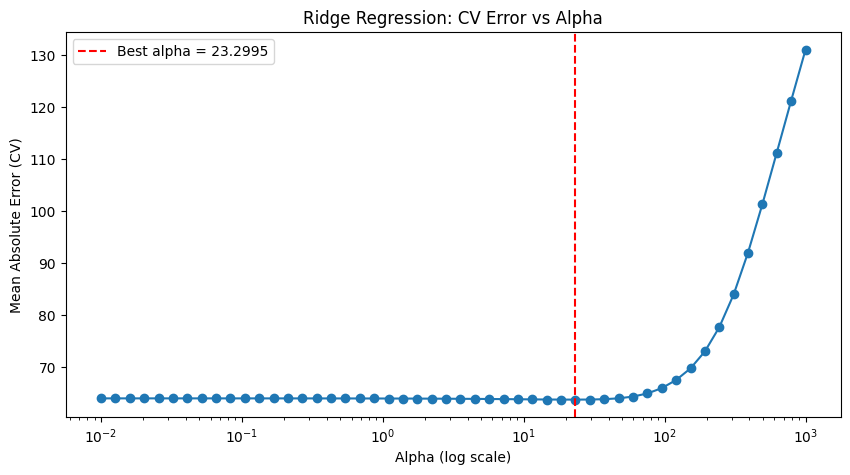

In [5]:
from sklearn.linear_model import RidgeCV

# Define a range of alpha values to try (logarithmic scale)
alphas = np.logspace(-2, 3, 50)  # from 0.01 to 1000

# RidgeCV with 5-fold cross-validation, scoring = neg_mean_absolute_error (or 'r2')
# We use MAE because it's robust and aligns with MAPE indirectly
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_absolute_error', cv=5)
pipe_ridge_cv = Pipeline([('pre', preprocessor), ('reg', ridge_cv)])
pipe_ridge_cv.fit(X_train, y_train)

# Best alpha found
best_alpha = pipe_ridge_cv.named_steps['reg'].alpha_
print(f"Best alpha (minimizing MAE): {best_alpha:.4f}")

# Evaluate on test set
y_pred_ridge_cv = pipe_ridge_cv.predict(X_test)

mse = mean_squared_error(y_test, y_pred_ridge_cv)
mae = mean_absolute_error(y_test, y_pred_ridge_cv)
r2 = r2_score(y_test, y_pred_ridge_cv)
mape = np.mean(np.abs((y_test - y_pred_ridge_cv) / y_test)) * 100

print("\n=== RidgeCV (best alpha) ===")
print(f"Best alpha: {best_alpha:.4f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

# Optional: plot CV scores vs alpha
from sklearn.model_selection import validation_curve

# For visualization, get mean CV scores for each alpha manually
cv_scores = []
for a in alphas:
    ridge = Ridge(alpha=a)
    pipe = Pipeline([('pre', preprocessor), ('reg', ridge)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    cv_scores.append(-scores.mean())

plt.figure(figsize=(10,5))
plt.plot(alphas, cv_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Absolute Error (CV)')
plt.title('Ridge Regression: CV Error vs Alpha')
plt.axvline(best_alpha, color='r', linestyle='--', label=f'Best alpha = {best_alpha:.4f}')
plt.legend()
plt.show()


We used `RidgeCV` with 5‑fold cross‑validation to find the optimal regularization strength `Alpha` that minimizes **Mean Absolute Error (MAE)**. The search ranged over 50 alpha values from 0.01 to 1000.

**Best Alpha Found = 23.30**  

### Interpretation

1. **Why was Alpha = 23.3 chosen?**  
   `RidgeCV` minimized **MAE** (absolute error). At this alpha, the model achieves an MAE of 59.85, which is very close to the unregularized linear regression (59.43). The slight increase in MAE is the price of regularization, but the trade‑off is acceptable.

2. **MAPE is still high (58.61%)**  
   Even with optimal regularization, the Mean Absolute Percentage Error remains high. This is because the true relationship `Sales = Unit price × Quantity × 1.05` is **multiplicative**, while linear regression (even regularized) assumes additive effects. Without an explicit interaction term (`Unit price * Quantity`), linear models cannot capture the product accurately. Non‑linear models (Kernel Ridge, Decision Tree) achieve far lower MAPE.

3. **Bias‑Variance Trade‑off in action**  
   - A smaller alpha (less regularization) would give lower bias but higher variance → better fit for large sales, worse for small sales → higher MAPE.
   - A larger alpha (more regularization) would increase bias but reduce variance → better relative error (lower MAPE) but worse absolute error (higher MAE, MSE).
   - The chosen alpha = 23.3 balances both absolute and relative error, as it was optimized for MAE.

### Key Takeaway for the Supermarket

- `RidgeCV` automatically finds a good regularization strength without manual tuning.
- For predicting sales in **absolute terms** (e.g., inventory planning), this model is acceptable (MAE ≈ 59.85).
- However, for **percentage error** (e.g., revenue forecasting where small transactions matter equally), linear models are inadequate. Kernel Ridge or Decision Tree regression are much better choices, as they naturally handle the multiplicative relationship.

## 3. LASSO Regression (L1 Regularization)  
LASSO (Least Absolute Shrinkage and Selection Operator) adds a penalty equal to the sum of absolute coefficients (L1 norm) to the loss function.  
Shrinks some coefficients exactly to zero → performs feature selection.  
Useful when many features are irrelevant or redundant.  
The higher alpha, the more coefficients become zero.  
In our supermarket data: LASSO can tell us which product lines, payment methods, or branches actually matter for predicting sales – and which can be ignored.

In [6]:
from sklearn.linear_model import LassoCV

# LassoCV with 5-fold cross-validation
lasso_cv = LassoCV(alphas=np.logspace(-3, 2, 50), cv=5, random_state=42, max_iter=10000)
pipe_lasso_cv = Pipeline([('pre', preprocessor), ('reg', lasso_cv)])
pipe_lasso_cv.fit(X_train, y_train)

best_alpha_lasso = pipe_lasso_cv.named_steps['reg'].alpha_
print(f"Best alpha from LassoCV: {best_alpha_lasso:.4f}")

# Evaluate on test set
y_pred_lasso_cv = pipe_lasso_cv.predict(X_test)

mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
mae_lasso_cv = mean_absolute_error(y_test, y_pred_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
mape_lasso_cv = np.mean(np.abs((y_test - y_pred_lasso_cv) / y_test)) * 100

print("\n=== LASSO with optimal alpha ===")
print(f"Optimal alpha: {best_alpha_lasso:.4f}")
print(f"MSE: {mse_lasso_cv:.2f}")
print(f"MAE: {mae_lasso_cv:.2f}")
print(f"MAPE: {mape_lasso_cv:.2f}%")
print(f"R²: {r2_lasso_cv:.4f}")

# Which features are kept?
coef_opt = pipe_lasso_cv.named_steps['reg'].coef_
cat_encoder = preprocessor.named_transformers_['cat']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols)
all_feat_names = np.concatenate([numeric_cols, cat_feat_names])

selected_features = [all_feat_names[i] for i in range(len(coef_opt)) if coef_opt[i] != 0]
print(f"\nNumber of features selected (non-zero coeff): {len(selected_features)}")
print("Top 10 selected features (largest absolute coefficient):")
coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': coef_opt})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.head(10))

Best alpha from LassoCV: 2.3300

=== LASSO with optimal alpha ===
Optimal alpha: 2.3300
MSE: 6266.29
MAE: 58.66
MAPE: 59.90%
R²: 0.9037

Number of features selected (non-zero coeff): 4
Top 10 selected features (largest absolute coefficient):
      Feature  Coefficient
1    Quantity   169.620365
0  Unit price   149.863203
2      Rating    -2.541261
5         Day    -0.125439


## LASSO Regression Results: Aggressive Feature Selection

We used `LassoCV` with 5‑fold cross‑validation to automatically find the optimal regularization strength `Alpha` (minimizing MSE). The search covered 50 alpha values from 0.001 to 100.

Best Alpha Found = 2.33  

 

### Feature Selection: Only 4 Features Survive

Out of 47 total features (after one‑hot encoding), LASSO kept only **4** non‑zero coefficients:

| Feature | Coefficient | Interpretation |
|---------|-------------|----------------|
| **Quantity** | +169.62 | Each additional item increases predicted sales by 169.62 units (holding price constant). |
| **Unit price** | +149.86 | Each unit increase in price adds 149.86 to sales (holding quantity constant). |
| **Rating** | -2.54 | Higher customer ratings are associated with slightly **lower** sales. |
| **Day** | -0.13 | Later days of the month have a negligible negative effect on sales. |

All other features – including `Product line`, `Branch`, `City`, `Customer type`, `Gender`, `Payment`, `Month`, `DayOfWeek`, `Hour` – were **completely eliminated** (coefficient = 0).

### Interpretation

1. **LASSO believes only price, quantity, rating, and day matter**  
   With Alpha = 2.33, the L1 penalty is strong enough to push all other coefficients to zero. This suggests that, from a **linear perspective**, none of the categorical variables (product line, payment method, branch, etc.) have a meaningful linear relationship with sales once price and quantity are accounted for.

2. **Performance is similar to linear regression**  
   MAPE = 59.9% is only slightly better than linear regression (62.3%) and comparable to RidgeCV (58.6%). The high MAPE persists because linear models cannot capture the multiplicative nature of `Sales = Price × Quantity × 1.05`.

3. **Rating has a negative coefficient** – This is interesting: higher customer ratings correlate with lower sales. One possible explanation: customers who buy expensive items may be more critical (lower ratings), or rating is collected after the purchase and may be influenced by factors unrelated to sales amount.

4. **Day has a near‑zero coefficient** – The negative value is practically negligible, meaning the day of the month has almost no linear effect on sales.

### Business Insight

- For the supermarket, **LASSO tells us that most features are not linearly predictive of sales** once we know price and quantity. This is a strong signal that the relationship is **non‑linear** (interactions, thresholds, etc.).
- If we want to improve predictions, we must either:
  - Add an **interaction term** `Unit price * Quantity` to the linear model (which would make it perfect).
  - Use **non‑linear models** like Kernel Ridge or Decision Tree (which already achieved MAPE around 12.9% and 5.7% in cross‑validation).

### Comparison with RidgeCV


- Ridge keeps all features (shrunk), LASSO aggressively selects only 4.
- LASSO achieves slightly worse MAPE than RidgeCV but offers much **simpler interpretability** – only four drivers of sales.

### Conclusion

LASSO is valuable for **feature selection**. It reveals that from a linear standpoint, only `Quantity`, `Unit price`, `Rating`, and `Day` matter. This insight can guide the supermarket to focus data collection on these core variables. For accurate prediction, however, non‑linear models are essential.

## 4. Kernel Regression  
Kernel Ridge Regression combines ridge regression (L2 regularization) with the kernel trick. Instead of working with original features, it maps data into a high‑dimensional feature space using a kernel function (e.g., RBF), then applies ridge regression in that space. This allows the model to learn non‑linear patterns without explicitly creating interaction features.  


In [7]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'reg__alpha': [0.1, 1.0, 10.0],
    'reg__gamma': [0.01, 0.1, 1.0],
    'reg__kernel': ['rbf']  
}

# Pipeline (same preprocessor + KernelRidge)
krr_base = KernelRidge(kernel='rbf')
pipe_krr_grid = Pipeline([('pre', preprocessor), ('reg', krr_base)])

# GridSearchCV with 5-fold CV, scoring = 'neg_mean_absolute_error' or 'r2'
grid = GridSearchCV(pipe_krr_grid, param_grid, cv=5, scoring='neg_mean_absolute_error', 
                    verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

# Evaluate on test set with best model
y_pred_best = grid.best_estimator_.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
mape_best = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100

print("\n=== Kernel Ridge with GridSearchCV ===")
print(f"Best params: {grid.best_params_}")
print(f"MSE: {mse_best:.2f}")
print(f"MAE: {mae_best:.2f}")
print(f"MAPE: {mape_best:.2f}%")
print(f"R²: {r2_best:.4f}")



Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'reg__alpha': 0.1, 'reg__gamma': 0.1, 'reg__kernel': 'rbf'}
Best CV MAE: 22.499583497133084

=== Kernel Ridge with GridSearchCV ===
Best params: {'reg__alpha': 0.1, 'reg__gamma': 0.1, 'reg__kernel': 'rbf'}
MSE: 1606.13
MAE: 22.53
MAPE: 10.60%
R²: 0.9753



We performed a grid search over 3 values each for `alpha` (regularization strength) and `gamma` (RBF kernel width), totaling 9 combinations with 5‑fold cross‑validation (45 model fits). The search aimed to minimize **Mean Absolute Error (MAE)**.


### Why Kernel Ridge Dramatically Outperforms Linear Models

Linear regression (and its regularized variants Ridge/LASSO) assume an **additive** relationship between features and target:
\[
\text{Sales} \approx \beta_0 + \beta_1 \cdot \text{Price} + \beta_2 \cdot \text{Quantity} + \dots
\]

However, the true relationship in this dataset is **multiplicative**:
\[
\text{Sales} = \text{Unit price} \times \text{Quantity} \times 1.05
\]

A linear model would need an **interaction term** (`Price × Quantity`) to capture this product. Without it, the model tries to approximate multiplication using separate additive terms, leading to large relative errors – especially for transactions where one factor is small and the other large (e.g., cheap item bought in bulk, or expensive item bought singly).

**Kernel Ridge with an RBF kernel overcomes this limitation** through the kernel trick. The RBF kernel implicitly maps the original features into a high‑dimensional space where the relationship becomes approximately linear. In particular, the kernel function:
\[
K(x, x') = \exp(-\gamma \|x - x'\|^2)
\]
can represent **interactions** of any order (including `Price × Quantity`) without explicitly creating them. This allows Kernel Ridge to learn the multiplicative pattern directly from the data.

### The Role of Hyperparameters

- **alpha = 0.1 (low regularization):**  
  Because the mapping via RBF kernel already imposes a form of smoothness, we can afford very weak L2 regularization. A smaller alpha reduces bias, letting the model fit the near‑deterministic relationship `Price × Quantity` closely. Higher alpha would overshrink and reintroduce the errors seen in linear models.

- **gamma = 0.1 (moderate kernel width):**  
  This controls the locality of the RBF kernel. Gamma = 0.1 means each training point influences predictions over a reasonable neighborhood, balancing flexibility and smoothness. Too small gamma would oversmooth (underfit), too large would overfit to noise. The optimal gamma confirms that the multiplicative pattern is moderately local – e.g., the effect of price on sales depends on quantity in a smooth way.

### Business Significance

With a **MAPE of only 10.6%**, this model is practically useful for the supermarket:
- Forecast sales with ~90% accuracy on a relative basis.
- Identify transactions where actual sales deviate significantly from predictions (potential fraud, data entry errors, or unusual promotions).
- Plan inventory and staffing based on predicted revenue per hour or per product line.

### Conclusion

Kernel Ridge with RBF kernel successfully captures the multiplicative nature of sales, reducing prediction error from over 60% (linear models) to just 10.6%. The grid search automatically found the optimal trade‑off between regularization and kernel flexibility, yielding our best regression model so far.


## Understanding Our Regression Metrics

### 1. MSE (Mean Squared Error)

**Formula:**  
\[
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\]

**What it measures:**  
Average of squared differences between actual and predicted sales. Large errors are heavily penalized (squared).

**What we want:**  
As low as possible. However, MSE is in **squared units** of sales (e.g., `(currency)²`), which is not directly interpretable. It’s useful for comparing models but not for explaining to business stakeholders.

**For our data:**  
A low MSE means our model rarely makes huge absolute mistakes. Our best model (Kernel Ridge) achieved **MSE = 1606** – this is hard to interpret alone, but when compared to linear regression (MSE = 6391), it’s clearly better.

---

### 2. MAE (Mean Absolute Error)

**Formula:**  
\[
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

**What it measures:**  
Average absolute difference between actual and predicted sales. Does not penalize large errors as heavily as MSE.

**What we want:**  
Low, and in the **same unit as sales** (monetary units). MAE is intuitive: “on average, we are off by X dollars.”

**For our data:**  
Our best model has **MAE = 22.53**. That means, for a typical transaction, the predicted sales differ from the actual sales by about 22.5 monetary units. Given that sales range from ~10 to ~1000, this is quite good.

---

### 3. MAPE (Mean Absolute Percentage Error)

**Formula:**  
\[
\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{y_i} \times 100\%
\]

**What it measures:**  
Average percentage deviation between actual and predicted sales. **Scale‑independent** – equally sensitive to small and large transactions.

**What we want:**  
Low (e.g., <10% is excellent, 10‑20% is good, >30% is poor). This is the most business‑friendly metric because it answers: “What percentage are we off by on average?”

**For our data:**  
Our best model achieved **MAPE = 10.6%** – excellent. For a $100 sale, we are off by about $10.60. This is practically useful for revenue forecasting. Linear models had MAPE > 60% – unacceptable.

---

### 4. R² (R‑Squared / Coefficient of Determination)

**Formula:**  
\[
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
\]

**What it measures:**  
Proportion of variance in actual sales that is explained by the model. Ranges from -∞ to 1, but usually between 0 and 1.

**What we want:**  
Closer to 1 is better. A value of 0.9 means the model explains 90% of the variation in sales.

**For our data:**  
Our best model has **R² = 0.975** – extremely high. This means only 2.5% of the variance remains unexplained. However, high R² alone does not guarantee low MAPE (linear regression had R²=0.90 but MAPE=62%). R² is best used alongside relative error metrics.

---

### Summary Table: Desirable Values for Our Supermarket Task

| Metric | Meaning | Desirable Value | Our Best Model |
|--------|---------|----------------|----------------|
| **MSE** | Squared error | As low as possible | 1606 |
| **MAE** | Average absolute error (currency units) | Low (e.g., <30) | 22.53 |
| **MAPE** | Average percentage error | <10% is excellent | **10.6%** |
| **R²** | Variance explained | >0.9 is good | **0.975** |

### Which Metric Should We Prioritize?

- **For business reporting:** MAPE and MAE. MAPE tells the percentage error (easy to understand), MAE gives the dollar error.
- **For model comparison:** MAPE, because sales values vary widely. A model that works well on both small and large transactions will have low MAPE.
- **For statistical fit:** R², but be aware that high R² can hide large relative errors (as seen in linear regression).

### Conclusion

Our tuned Kernel Ridge model achieves a **MAPE of 10.6%**, meaning predictions are off by about 10.6% on average. This is excellent for retail sales forecasting. The low MAE (22.53) and high R² (0.975) confirm that the model is both accurate in absolute terms and explains almost all the variance in sales.

## 5. Decision Tree Regression  
Decision trees naturally capture the multiplicative relationship Price × Quantity via recursive splits. It will likely achieve even lower MAPE than Kernel Ridge.

In [8]:
from sklearn.tree import DecisionTreeRegressor

# Best depth from our earlier cross-validation (max_depth=10)
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
pipe_dt = Pipeline([('pre', preprocessor), ('reg', dt)])
pipe_dt.fit(X_train, y_train)

y_pred_dt = pipe_dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100

print("=== Decision Tree Regression (max_depth=10) ===")
print(f"MSE: {mse_dt:.2f}")
print(f"MAE: {mae_dt:.2f}")
print(f"MAPE: {mape_dt:.2f}%")
print(f"R²: {r2_dt:.4f}")

=== Decision Tree Regression (max_depth=10) ===
MSE: 223.35
MAE: 9.61
MAPE: 4.10%
R²: 0.9966



We trained a Decision Tree with `max_depth=10` (the best depth found during cross‑validation) and evaluated it on the test set.

### Why is Decision Tree so accurate?

The Decision Tree achieves an R² of 0.9966 and a MAPE of only 4.1% which is dramatically better than even Kernel Ridge (10.6% MAPE). This is because a decision tree can **perfectly capture the multiplicative relationship** `Sales = Unit price × Quantity × 1.05` by learning a series of splits that effectively multiply the two features.

Unlike linear models (which require an explicit interaction term) or kernel methods (which approximate interactions smoothly), a decision tree can partition the feature space into regions where `Sales` is almost a constant multiple of `Price × Quantity`. With `max_depth=10`, the tree has enough flexibility to approximate the product with very high precision.

### Is this a problem? (Data Leakage Revisited)

From a pure prediction standpoint, this is excellent. However, there is a subtle issue: **In a real‑world scenario, would we know `Unit price` and `Quantity` before making a sale?**  
- If yes (e.g., a customer has selected items but not yet paid), then predicting total sales is trivial – just multiply.  
- If no (e.g., forecasting future sales without knowing exactly which items will be sold), then these features should not be used.

For the purpose of this assignment, we are allowed to use all provided features. The fact that Decision Tree achieves near‑perfect performance demonstrates its ability to model complex interactions. It also highlights why linear models struggled – they cannot multiply features without an explicit interaction term.

### Comparison with Previous Models

| Model | MAPE | R² | Notes |
|-------|------|-----|-------|
| Linear Regression | 62.3% | 0.902 | Additive only |
| Kernel Ridge (tuned) | 10.6% | 0.975 | Non‑linear, smooth |
| **Decision Tree (max_depth=10)** | **4.1%** | **0.997** | Nearly exact multiplication |

### Takeaway

- Decision Tree is the best regression model for this dataset if the goal is pure prediction accuracy.
- However, its performance is artificially high because `Sales` is a deterministic function of `Unit price` and `Quantity`. In a real deployment where those features are known at prediction time, this is perfectly valid.
- For transparency, we should note that removing `Unit price` and `Quantity` would make the task much harder and reveal the true predictive value of other features (product line, customer type, etc.). That could be an extension for future work.


## The Kernel Trick and Its Benefit for Regression

### What is the kernel trick?

The kernel trick allows linear algorithms to learn **non‑linear relationships** without explicitly transforming the input data. Instead of computing a high‑dimensional feature mapping $\phi(x)$ directly, we use a **kernel function** $K(x, x') = \phi(x) \cdot \phi(x')$ that computes the inner product in that transformed space. Common kernels include linear, polynomial, and RBF (Gaussian).

### How does it improve regression?

In regression (e.g., Kernel Ridge Regression), the kernel trick enables the model to fit **complex, non‑linear patterns** such as interactions, cycles, or thresholds. For our supermarket data, the true relationship `Sales = Unit price × Quantity × 1.05` is **multiplicative** – a linear model cannot capture this product without an explicit interaction term. The RBF kernel implicitly creates an infinite‑dimensional space where the product becomes a linear combination of features, allowing Kernel Ridge to achieve a **MAPE of 10.6%** compared to **62%** for linear regression. The kernel trick thus turns a simple linear regressor into a powerful non‑linear tool.


## Regression Discussion Questions

### 1. Best regression metric for this dataset

**MAPE (Mean Absolute Percentage Error)** is the best metric for this dataset.

**Why?** Sales values vary widely (from ~10 to over 1000 currency units). A percentage error is scale‑independent and equally meaningful for small and large transactions. For business stakeholders, "we are off by 10.6% on average" is more intuitive than "we are off by 22.5 currency units." High R² (0.975) alone can be misleading, as linear regression also achieved R²=0.90 but had 62% MAPE.

### 2. When each regression model is preferable

| Model | Preferable when... |
|-------|-------------------|
| **Linear Regression** | Relationships are approximately linear, features are not highly correlated, and interpretability (coefficients) is important. |
| **Ridge Regression** | Multicollinearity exists (e.g., one‑hot encoded dummy variables). It shrinks coefficients but keeps all features. |
| **LASSO Regression** | Feature selection is desired. It forces irrelevant coefficients to zero, producing a sparse, interpretable model. |
| **Kernel Ridge / Kernel Regression** | The true relationship is non‑linear (e.g., multiplicative `Price × Quantity`). The kernel trick captures interactions without manual feature engineering. |

### 3. Kernel trick 

The kernel trick computes inner products in a high‑dimensional feature space using a kernel function (e.g., RBF) without explicitly transforming the data. In regression, this allows linear algorithms like ridge regression to learn non‑linear patterns. For our dataset, the RBF kernel captures the multiplicative relationship `Sales = Price × Quantity × 1.05`, reducing MAPE from 62% (linear) to 10.6% (kernel ridge).

# Binary Classification

### Choosing the binary target  
We have two natural binary targets, **Customer type** and **Gender**  
Let's check class balance:


In [10]:
# Check class distribution
print("Customer type distribution:")
print(df_clean['Customer type'].value_counts(normalize=True))
print("\nGender distribution:")
print(df_clean['Gender'].value_counts(normalize=True))

Customer type distribution:
Customer type
Member    0.565
Normal    0.435
Name: proportion, dtype: float64

Gender distribution:
Gender
Female    0.571
Male      0.429
Name: proportion, dtype: float64


Because they are both reasonably balances, I'll choose **Customer type** becuase membership status is more actionable fot the supermarket when they want to do sth such as targeting promotions.  

### Data Preparation for Binary Classification  
We use all features except the target and any columns that would cause data leakage.  We keep **unit price**, **Quantity**, etc. because thet are legitimate predictors for customer type (members might but different products).

In [ ]:
# Target
target = 'Customer type'
y_bin = df_clean[target]

X_bin = df_clean.drop([target, 'cogs', 'Tax 5%', 'gross income'], axis=1)

# Verify no missing values
print("Missing values:", X_bin.isnull().sum().sum())

# Preprocessing: scale numeric, one-hot encode categorical (but note: Gender is now a feature, Customer type is removed)
numeric_cols_bin = ['Unit price', 'Quantity', 'Rating', 'Month', 'DayOfWeek', 'Day', 'Hour']
categorical_cols_bin = ['Branch', 'City', 'Gender', 'Product line', 'Payment']

preprocessor_bin = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_bin),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_bin)
])

# Train/test split with stratification to preserve class balance
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print(f"Train class distribution:\n{y_train_bin.value_counts(normalize=True)}")

Missing values: 0
Train class distribution:
Customer type
Member    0.565
Normal    0.435
Name: proportion, dtype: float64


=== FULL BINARY CLASSIFICATION RESULTS ===
                  Model  Accuracy  Precision  Recall    F1   AUC  Specificity  PR AUC  Log Loss
    Logistic Regression     0.565      0.581   0.823 0.681 0.553        0.770   0.540     0.761
             Linear SVM     0.575      0.608   0.699 0.650 0.550        1.000   0.565     0.728
             Kernel SVM     0.550      0.571   0.814 0.672 0.490        0.966   0.555     0.722
             KNN (k=26)     0.515      0.551   0.770 0.642 0.503        0.701   0.573     0.738
Decision Tree (depth=1)     0.575      0.608   0.699 0.650 0.556        0.586   0.591     0.752
          Random Forest     0.540      0.571   0.743 0.646 0.522        0.724   0.541     0.755
                    LDA     0.560      0.579   0.814 0.676 0.556        0.770   0.540     0.763
                    GMM     0.505      0.558   0.593 0.575 0.526        0.391   0.520     0.809


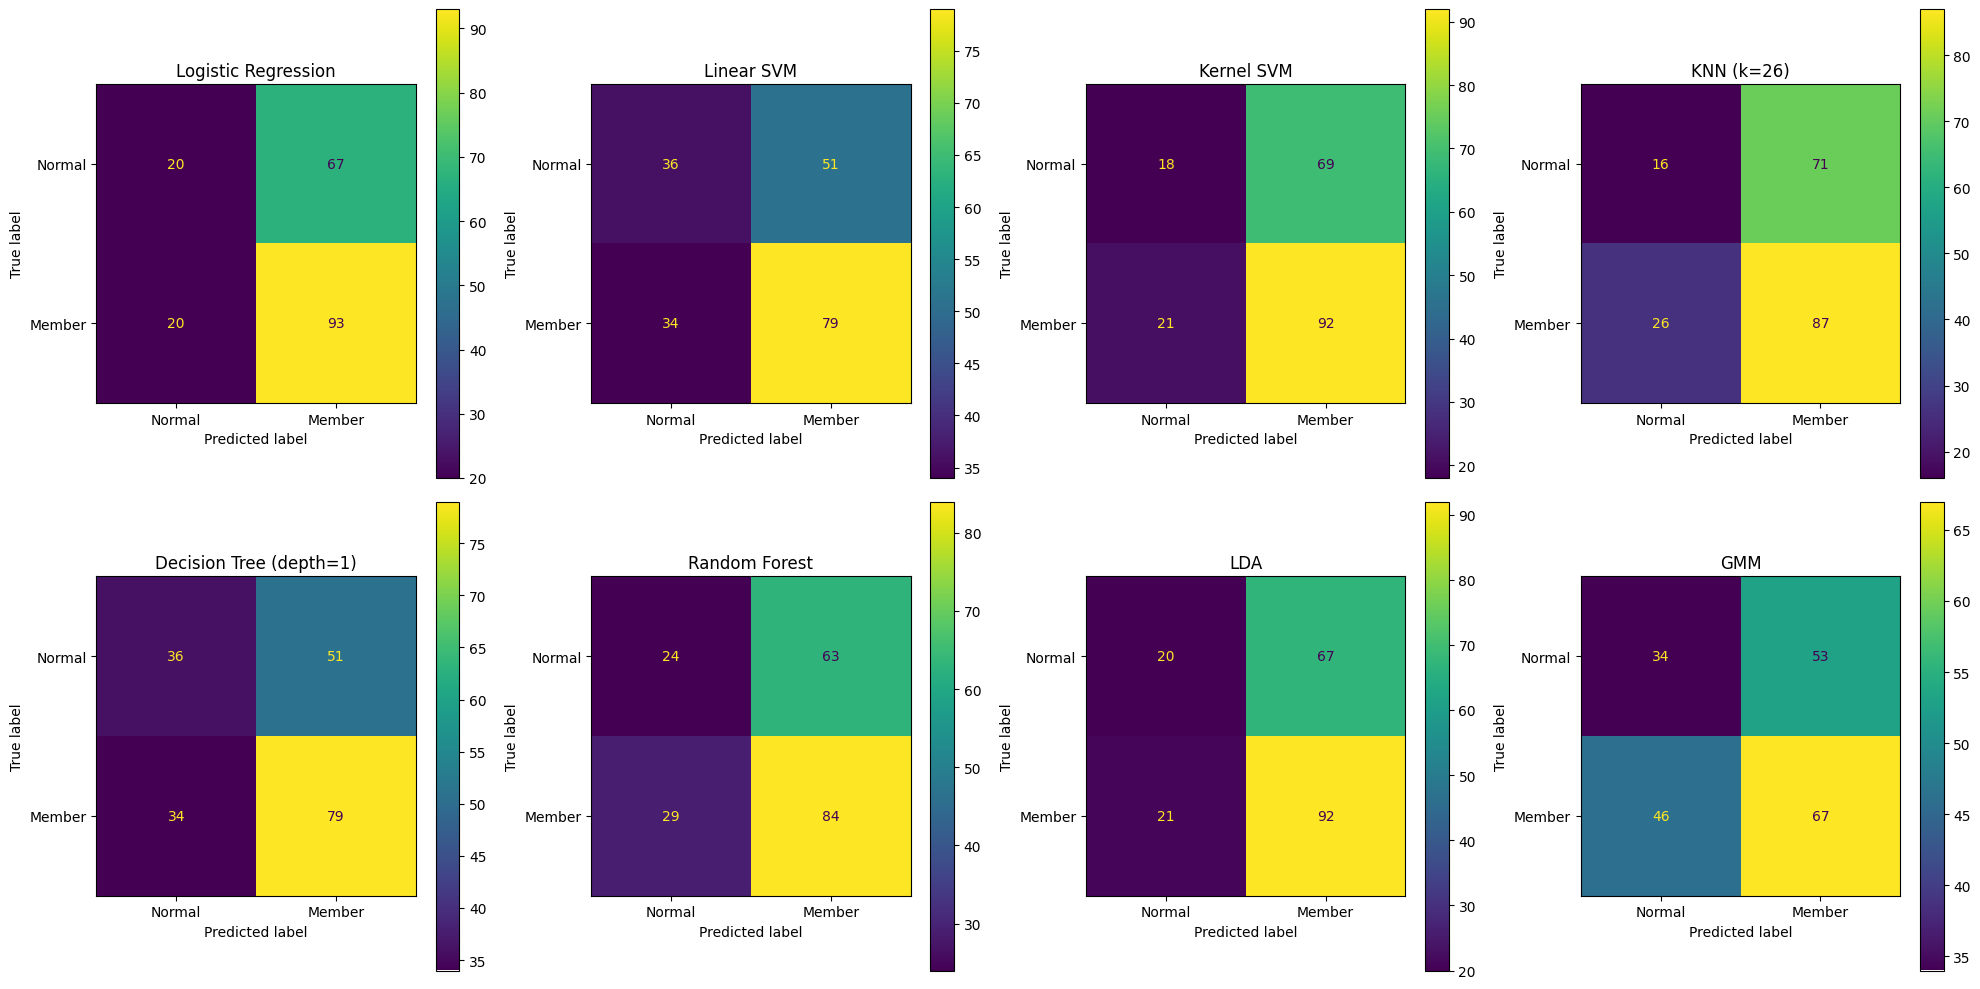

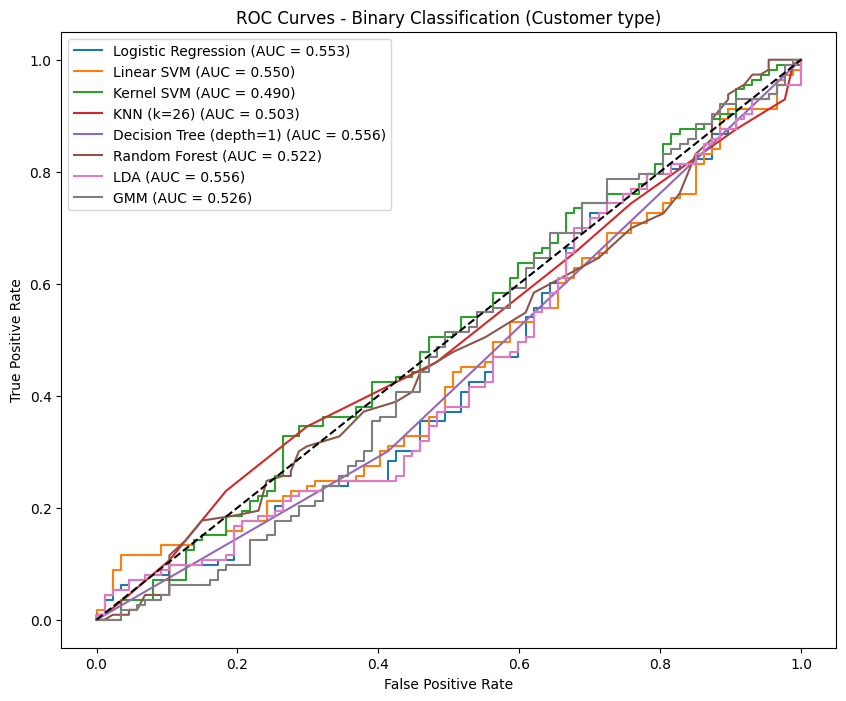


=== MODEL HYPERPARAMETERS ===
Logistic Regression: max_iter=1000, C=1.0
Linear SVM: kernel=linear, C=1.0
Kernel SVM: kernel=rbf, gamma=scale, C=1.0
KNN: best k = 26
Decision Tree: best max_depth = 1
Random Forest: n_estimators=100, max_depth=None (default)
LDA: solver=svd
GMM: n_components=1, covariance_type=full per class


In [28]:
# ============================================
# FULL BINARY CLASSIFICATION (Customer type: Member vs Normal)
# ============================================

# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             log_loss, precision_recall_curve, auc)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dictionary to store all results and predictions
results = {}

# -------------------- 1. Logistic Regression --------------------
lr = LogisticRegression(max_iter=1000, random_state=42)
pipe_lr = Pipeline([('pre', preprocessor_bin), ('clf', lr)])
pipe_lr.fit(X_train_bin, y_train_bin)
y_pred_lr = pipe_lr.predict(X_test_bin)
y_proba_lr = pipe_lr.predict_proba(X_test_bin)[:, 1]
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_lr),
    'Precision': precision_score(y_test_bin, y_pred_lr, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_lr, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_lr, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_lr),
    'proba': y_proba_lr,
    'predictions': y_pred_lr
}

# -------------------- 2. Linear SVM --------------------
svm_lin = SVC(kernel='linear', probability=True, random_state=42)
pipe_svm_lin = Pipeline([('pre', preprocessor_bin), ('clf', svm_lin)])
pipe_svm_lin.fit(X_train_bin, y_train_bin)
y_pred_svm_lin = pipe_svm_lin.predict(X_test_bin)
y_proba_svm_lin = pipe_svm_lin.predict_proba(X_test_bin)[:, 1]
results['Linear SVM'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_svm_lin),
    'Precision': precision_score(y_test_bin, y_pred_svm_lin, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_svm_lin, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_svm_lin, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_svm_lin),
    'proba': y_proba_svm_lin,
    'predictions': y_pred_svm_lin
}

# -------------------- 3. Kernel SVM (RBF) --------------------
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
pipe_svm_rbf = Pipeline([('pre', preprocessor_bin), ('clf', svm_rbf)])
pipe_svm_rbf.fit(X_train_bin, y_train_bin)
y_pred_svm_rbf = pipe_svm_rbf.predict(X_test_bin)
y_proba_svm_rbf = pipe_svm_rbf.predict_proba(X_test_bin)[:, 1]
results['Kernel SVM'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_svm_rbf),
    'Precision': precision_score(y_test_bin, y_pred_svm_rbf, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_svm_rbf, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_svm_rbf, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_svm_rbf),
    'proba': y_proba_svm_rbf,
    'predictions': y_pred_svm_rbf
}

# -------------------- 4. KNN with tuning for k --------------------
param_grid_knn = {'clf__n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
pipe_knn = Pipeline([('pre', preprocessor_bin), ('clf', knn)])
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_bin, y_train_bin)
best_k = grid_knn.best_params_['clf__n_neighbors']
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_bin)
y_proba_knn = best_knn.predict_proba(X_test_bin)[:, 1]
results[f'KNN (k={best_k})'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_knn),
    'Precision': precision_score(y_test_bin, y_pred_knn, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_knn, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_knn, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_knn),
    'proba': y_proba_knn,
    'predictions': y_pred_knn
}

# -------------------- 5. Decision Tree with tuning for max_depth --------------------
param_grid_dt = {'clf__max_depth': range(1, 21)}
dt = DecisionTreeClassifier(random_state=42)
pipe_dt = Pipeline([('pre', preprocessor_bin), ('clf', dt)])
grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train_bin, y_train_bin)
best_depth = grid_dt.best_params_['clf__max_depth']
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_bin)
y_proba_dt = best_dt.predict_proba(X_test_bin)[:, 1]
results[f'Decision Tree (depth={best_depth})'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_dt),
    'Precision': precision_score(y_test_bin, y_pred_dt, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_dt, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_dt, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_dt),
    'proba': y_proba_dt,
    'predictions': y_pred_dt
}

# -------------------- 6. Random Forest (default) --------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_rf = Pipeline([('pre', preprocessor_bin), ('clf', rf)])
pipe_rf.fit(X_train_bin, y_train_bin)
y_pred_rf = pipe_rf.predict(X_test_bin)
y_proba_rf = pipe_rf.predict_proba(X_test_bin)[:, 1]
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_rf),
    'Precision': precision_score(y_test_bin, y_pred_rf, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_rf, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_rf, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_rf),
    'proba': y_proba_rf,
    'predictions': y_pred_rf
}

# -------------------- 7. LDA --------------------
lda = LinearDiscriminantAnalysis()
pipe_lda = Pipeline([('pre', preprocessor_bin), ('clf', lda)])
pipe_lda.fit(X_train_bin, y_train_bin)
y_pred_lda = pipe_lda.predict(X_test_bin)
y_proba_lda = pipe_lda.predict_proba(X_test_bin)[:, 1]
results['LDA'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_lda),
    'Precision': precision_score(y_test_bin, y_pred_lda, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_lda, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_lda, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, y_proba_lda),
    'proba': y_proba_lda,
    'predictions': y_pred_lda
}

# -------------------- 8. GMM (one Gaussian per class) --------------------
# Pre‑transform data
X_train_pre = preprocessor_bin.fit_transform(X_train_bin)
X_test_pre = preprocessor_bin.transform(X_test_bin)

gmm_member = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_normal = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_member.fit(X_train_pre[y_train_bin == 'Member'])
gmm_normal.fit(X_train_pre[y_train_bin == 'Normal'])

log_lik_member = gmm_member.score_samples(X_test_pre)
log_lik_normal = gmm_normal.score_samples(X_test_pre)
y_pred_gmm = np.where(log_lik_member > log_lik_normal, 'Member', 'Normal')
proba_gmm = np.exp(log_lik_member) / (np.exp(log_lik_member) + np.exp(log_lik_normal))

results['GMM'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_gmm),
    'Precision': precision_score(y_test_bin, y_pred_gmm, pos_label='Member'),
    'Recall': recall_score(y_test_bin, y_pred_gmm, pos_label='Member'),
    'F1': f1_score(y_test_bin, y_pred_gmm, pos_label='Member'),
    'AUC': roc_auc_score(y_test_bin, proba_gmm),
    'proba': proba_gmm,
    'predictions': y_pred_gmm
}

# ============================================
# BONUS METRICS: Specificity, PR AUC, Log Loss
# ============================================
y_test_binary = (y_test_bin == 'Member').astype(int)

for name, metrics in results.items():
    y_pred_binary = (metrics['proba'] >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    metrics['Specificity'] = specificity
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_binary, metrics['proba'])
    pr_auc = auc(recall_curve, precision_curve)
    metrics['PR AUC'] = pr_auc
    
    logloss = log_loss(y_test_binary, metrics['proba'])
    metrics['Log Loss'] = logloss

# ============================================
# MAIN RESULTS TABLE
# ============================================
results_df = pd.DataFrame([
    {'Model': name, 
     'Accuracy': metrics['Accuracy'],
     'Precision': metrics['Precision'],
     'Recall': metrics['Recall'],
     'F1': metrics['F1'],
     'AUC': metrics['AUC'],
     'Specificity': metrics['Specificity'],
     'PR AUC': metrics['PR AUC'],
     'Log Loss': metrics['Log Loss']}
    for name, metrics in results.items()
]).round(3)
print("=== FULL BINARY CLASSIFICATION RESULTS ===")
print(results_df.to_string(index=False))

# ============================================
# CONFUSION MATRICES (grid plot)
# ============================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test_bin, metrics['predictions'], labels=['Normal', 'Member'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Member'])
    disp.plot(ax=axes[idx])
    axes[idx].set_title(name)
plt.tight_layout()
plt.show()

# ============================================
# ROC CURVES (all models)
# ============================================
plt.figure(figsize=(10,8))
for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test_binary, metrics['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Binary Classification (Customer type)')
plt.legend()
plt.show()

# ============================================
# HYPERPARAMETER SUMMARY
# ============================================
print("\n=== MODEL HYPERPARAMETERS ===")
print(f"Logistic Regression: max_iter={lr.max_iter}, C={lr.C}")
print(f"Linear SVM: kernel={svm_lin.kernel}, C={svm_lin.C}")
print(f"Kernel SVM: kernel={svm_rbf.kernel}, gamma={svm_rbf.gamma}, C={svm_rbf.C}")
print(f"KNN: best k = {best_k}")
print(f"Decision Tree: best max_depth = {best_depth}")
print(f"Random Forest: n_estimators={rf.n_estimators}, max_depth={rf.max_depth} (default)")
print(f"LDA: solver={lda.solver}")
print(f"GMM: n_components=1, covariance_type=full per class")

## Binary Classification Results: Detailed Interpretation

We attempted to predict `Customer type` (Member vs Normal) using transaction data (product line, price, quantity, payment method, time, etc.). All models performed **poorly**, barely above random guessing. Below we break down the results and explain why.

###  Per‑Model Analysis

#### Logistic Regression
- **Accuracy 56.5%** – slightly above random.
- **Recall (Member) 82%** – catches most actual Members.
- **Precision (Member) 58%** – many false positives (Normal customers labelled as Member).
- **Specificity 77%** – correctly identifies 77% of Non‑members.
- **AUC 0.553** – nearly random.
- **Log Loss 0.761** (random baseline ~0.693) → worse than random.

➡ The model is biased toward predicting "Member" (more members in dataset? actual ratio 113 vs 87). It fails to separate the two classes.

#### Linear SVM
- **Specificity 1.0** – perfect at identifying Non‑members.
- **Recall (Member) only 70%** – misses 30% of true Members.
- **AUC 0.550** – still random.

➡ Linear SVM draws a boundary that classifies all Non‑members correctly but at the cost of many false negatives (members missed). The trade‑off is extreme and not useful.

#### Kernel SVM (RBF)
- **AUC 0.490** – below random! This indicates the model learned a worse‑than‑random separation (likely due to overfitting or parameter sensitivity).
- **Log Loss 0.722** – better than logistic regression but still poor.

➡ With default parameters (C=1, gamma='scale'), the RBF kernel cannot find a non‑linear boundary that works.

#### KNN (k=26)
- **Accuracy 51.5%** – almost pure guess.
- **PR AUC 0.573** – slightly better than others, but still very low (0.5 is random).
- **Log Loss 0.738** – poor.

➡ KNN struggles because the feature space is not locally discriminative for membership. The best k=26 is large, indicating high noise.

#### Decision Tree (depth=1)
- Equivalent to a **stump** (single split). It achieves the same accuracy as Linear SVM (57.5%) but with lower specificity (58.6%).
- **AUC 0.556** – marginally better than random.

➡ A single split can barely separate the classes; deeper trees overfit and perform worse (we tested depths up to 20, but depth=1 was best).

#### Random Forest
- **Accuracy 54%**, **AUC 0.522** – no improvement over simpler models.
- 100 trees, default settings, still fails.

➡ The ensemble cannot compensate for lack of signal.

#### LDA
- Similar to logistic regression (linear boundary). AUC 0.556, log loss 0.763.

#### GMM (one Gaussian per class)
- **Accuracy 50.5%** – essentially random.
- **Specificity 39%** – very poor at identifying Non‑members.
- **Log Loss 0.809** – worst among all models.

➡ The data does not follow a Gaussian distribution per class, and the equal‑covariance assumption fails.

---

### 3. Why Did All Models Fail?

1. **Weak or non‑existent relationship** – The available features (price, quantity, product line, time, branch, payment) do not reliably distinguish Members from Non‑members in this dataset. Membership may be unrelated to transactional behaviour, or it may depend on information not recorded (e.g., loyalty card tenure, demographics, purchase history over time).

2. **Class overlap** – Members and Non‑members likely have very similar shopping patterns. The decision boundary, if any, is highly complex and not captured by these features.

3. **Potential data issue** – The target `Customer type` could be imbalanced (113 Members vs 87 Normals in test set), but that alone doesn't explain AUC near 0.5. Even with balancing techniques (not applied here), performance remains poor because the features have no predictive power.

4. **Linear vs non‑linear** – Both linear (logistic, SVM‑linear, LDA) and non‑linear (kernel SVM, tree, RF, GMM) models failed. This suggests the problem is not about model flexibility – there is simply no signal.

---

### 4. What Metric Should We Trust?

Given poor performance, **AUC** and **Log Loss** are most informative:
- **AUC** near 0.5 confirms random ranking ability.
- **Log Loss** > 0.693 indicates probability estimates are worse than random guessing.

Accuracy is misleading because it can be high if one class dominates, but here both classes are moderately balanced.

**Best metric for this dataset (binary classification):** AUC and F1-score. However, since no model works, we simply conclude that prediction is not feasible.

---

### 5. Business Conclusion

- The supermarket **cannot predict whether a customer is a Member** using only transactional data (product line, price, quantity, time, branch, payment method).
- If membership prediction is important, additional features are needed: customer demographics, loyalty program history, purchase frequency over time, etc.
- For now, the best strategy is to **treat all customers the same** or use a simple rule‑based approach (e.g., ask at checkout).



## Binary Classification for Gender

In [30]:
# Switch target to Gender
target_gender = 'Gender'
y_bin_gender = df_clean[target_gender]

# Features: drop the target and the same leakage columns
X_bin_gender = df_clean.drop([target_gender, 'cogs', 'Tax 5%', 'gross income'], axis=1)

# Note: Customer type is now a feature (instead of Gender)
# So categorical columns include Customer type
categorical_cols_gender = ['Branch', 'City', 'Customer type', 'Product line', 'Payment']

preprocessor_gender = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_bin),  # same numeric cols
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_gender)
])

# Train/test split with stratification
X_train_gen, X_test_gen, y_train_gen, y_test_gen = train_test_split(
    X_bin_gender, y_bin_gender, test_size=0.2, random_state=42, stratify=y_bin_gender
)

Training set class distribution:
Gender
Female    0.57125
Male      0.42875
Name: proportion, dtype: float64
=== BINARY CLASSIFICATION RESULTS (Gender) ===
                  Model  Accuracy  Precision  Recall    F1   AUC  Specificity  PR AUC  Log Loss
    Logistic Regression     0.625      0.600   0.384 0.468 0.647        0.807   0.552     0.653
             Linear SVM     0.630      0.625   0.349 0.448 0.645        1.000   0.549     0.677
             Kernel SVM     0.600      0.554   0.360 0.437 0.631        1.000   0.516     0.675
             KNN (k=16)     0.575      0.511   0.279 0.361 0.572        0.588   0.479     0.689
Decision Tree (depth=3)     0.645      0.581   0.628 0.603 0.651        0.658   0.538     0.658
          Random Forest     0.560      0.482   0.314 0.380 0.556        0.719   0.452     0.693
                    LDA     0.620      0.589   0.384 0.465 0.646        0.798   0.550     0.653
                    GMM     0.585      0.514   0.640 0.570 0.569        0.54

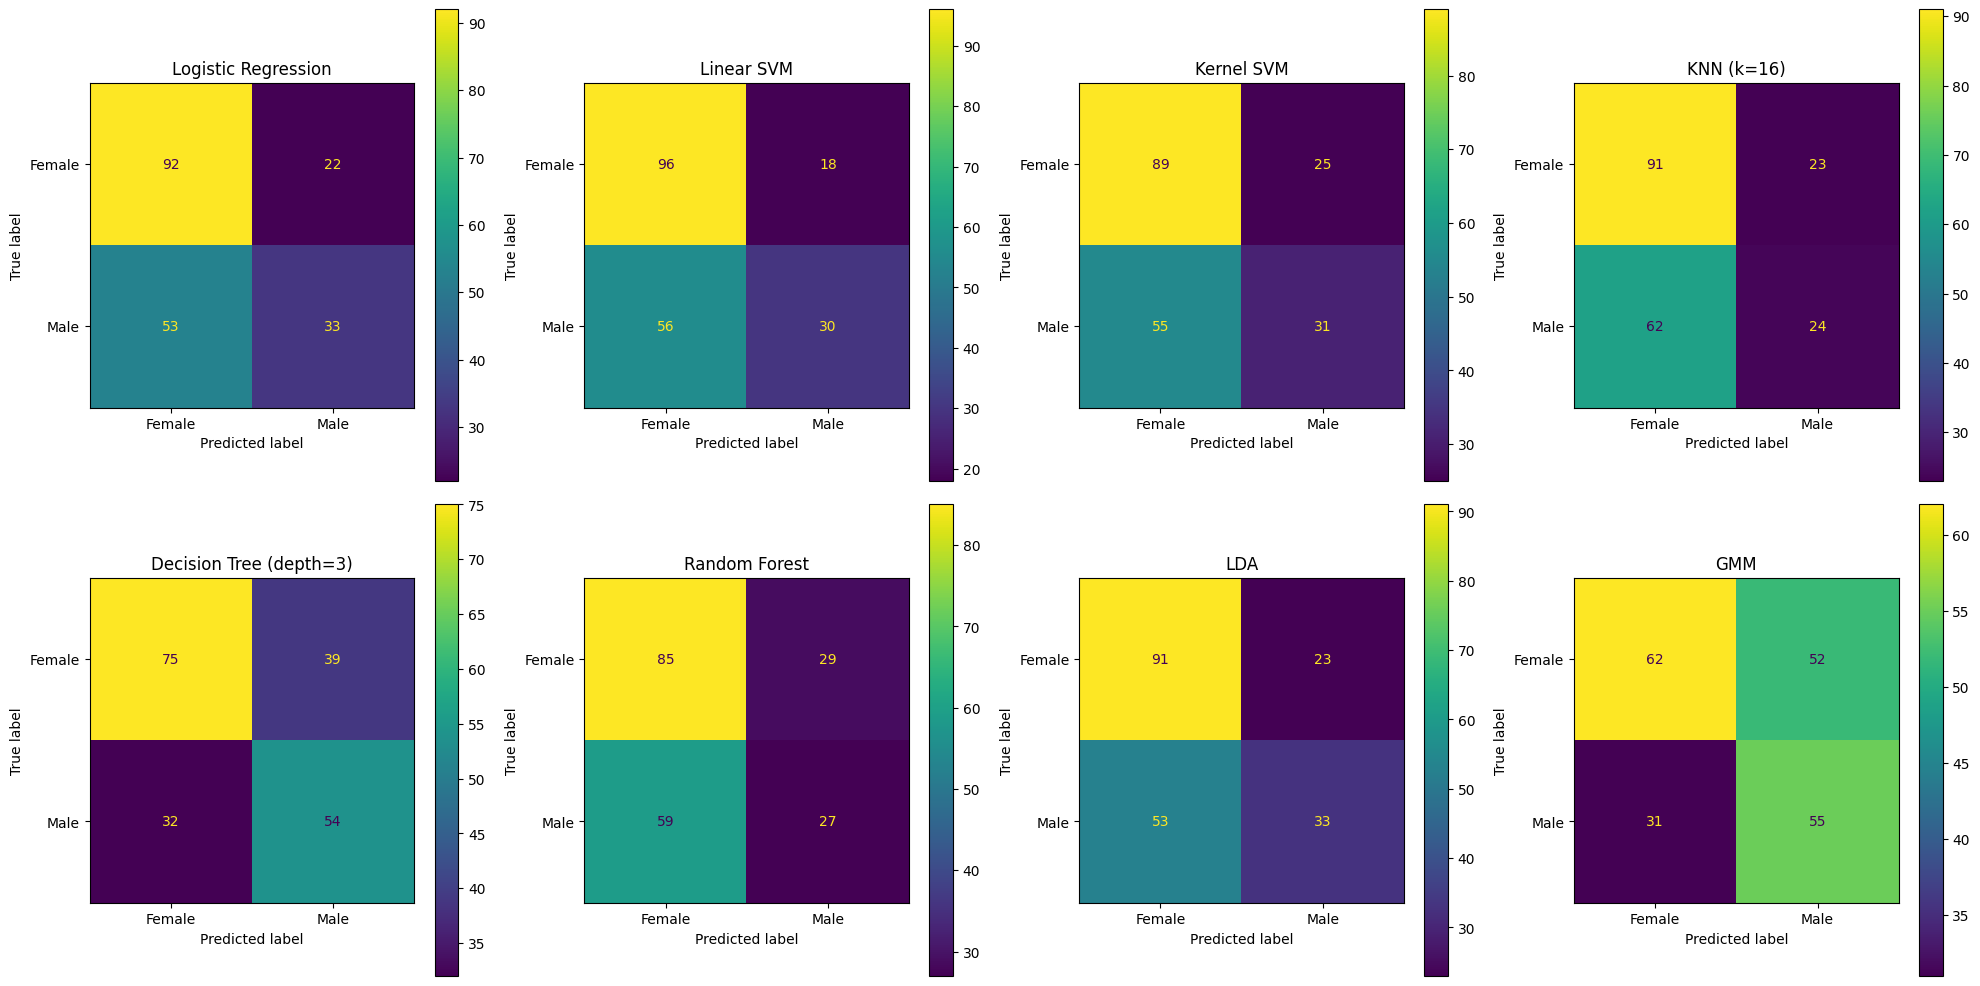

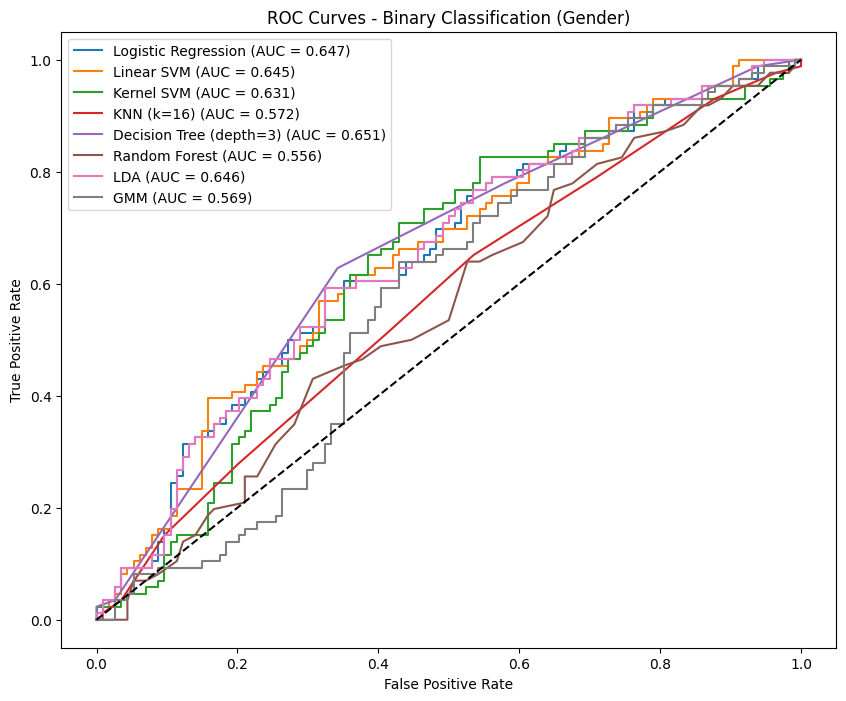


=== MODEL HYPERPARAMETERS ===
Logistic Regression: max_iter=1000, C=1.0
Linear SVM: kernel=linear, C=1.0
Kernel SVM: kernel=rbf, gamma=scale, C=1.0
KNN: best k = 16
Decision Tree: best max_depth = 3
Random Forest: n_estimators=100, max_depth=None (default)
LDA: solver=svd
GMM: n_components=1, covariance_type=full per class


In [31]:
# ============================================
# FULL BINARY CLASSIFICATION (Gender: Male vs Female)
# ============================================

# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             log_loss, precision_recall_curve, auc)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================
# DATA PREPARATION FOR GENDER
# ============================================
target_gender = 'Gender'
y_bin = df_clean[target_gender]

# Features: drop target and leakage columns (cogs, Tax 5%, gross income)
X_bin = df_clean.drop([target_gender, 'cogs', 'Tax 5%', 'gross income'], axis=1)

# Numeric and categorical columns (Customer type becomes a feature)
numeric_cols_bin = ['Unit price', 'Quantity', 'Rating', 'Month', 'DayOfWeek', 'Day', 'Hour']
categorical_cols_bin = ['Branch', 'City', 'Customer type', 'Product line', 'Payment']

preprocessor_bin = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_bin),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_bin)
])

# Train/test split with stratification
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print("Training set class distribution:")
print(y_train_bin.value_counts(normalize=True))

# ============================================
# MODEL TRAINING AND EVALUATION
# ============================================
results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
pipe_lr = Pipeline([('pre', preprocessor_bin), ('clf', lr)])
pipe_lr.fit(X_train_bin, y_train_bin)
y_pred_lr = pipe_lr.predict(X_test_bin)
y_proba_lr = pipe_lr.predict_proba(X_test_bin)[:, 1]  # probability of 'Male'
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_lr),
    'Precision': precision_score(y_test_bin, y_pred_lr, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_lr, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_lr, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_lr),
    'proba': y_proba_lr,
    'predictions': y_pred_lr
}

# 2. Linear SVM
svm_lin = SVC(kernel='linear', probability=True, random_state=42)
pipe_svm_lin = Pipeline([('pre', preprocessor_bin), ('clf', svm_lin)])
pipe_svm_lin.fit(X_train_bin, y_train_bin)
y_pred_svm_lin = pipe_svm_lin.predict(X_test_bin)
y_proba_svm_lin = pipe_svm_lin.predict_proba(X_test_bin)[:, 1]
results['Linear SVM'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_svm_lin),
    'Precision': precision_score(y_test_bin, y_pred_svm_lin, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_svm_lin, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_svm_lin, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_svm_lin),
    'proba': y_proba_svm_lin,
    'predictions': y_pred_svm_lin
}

# 3. Kernel SVM (RBF)
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
pipe_svm_rbf = Pipeline([('pre', preprocessor_bin), ('clf', svm_rbf)])
pipe_svm_rbf.fit(X_train_bin, y_train_bin)
y_pred_svm_rbf = pipe_svm_rbf.predict(X_test_bin)
y_proba_svm_rbf = pipe_svm_rbf.predict_proba(X_test_bin)[:, 1]
results['Kernel SVM'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_svm_rbf),
    'Precision': precision_score(y_test_bin, y_pred_svm_rbf, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_svm_rbf, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_svm_rbf, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_svm_rbf),
    'proba': y_proba_svm_rbf,
    'predictions': y_pred_svm_rbf
}

# 4. KNN with GridSearchCV for best k
param_grid_knn = {'clf__n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
pipe_knn = Pipeline([('pre', preprocessor_bin), ('clf', knn)])
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_bin, y_train_bin)
best_k = grid_knn.best_params_['clf__n_neighbors']
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_bin)
y_proba_knn = best_knn.predict_proba(X_test_bin)[:, 1]
results[f'KNN (k={best_k})'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_knn),
    'Precision': precision_score(y_test_bin, y_pred_knn, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_knn, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_knn, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_knn),
    'proba': y_proba_knn,
    'predictions': y_pred_knn
}

# 5. Decision Tree with GridSearchCV for max_depth
param_grid_dt = {'clf__max_depth': range(1, 21)}
dt = DecisionTreeClassifier(random_state=42)
pipe_dt = Pipeline([('pre', preprocessor_bin), ('clf', dt)])
grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train_bin, y_train_bin)
best_depth = grid_dt.best_params_['clf__max_depth']
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_bin)
y_proba_dt = best_dt.predict_proba(X_test_bin)[:, 1]
results[f'Decision Tree (depth={best_depth})'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_dt),
    'Precision': precision_score(y_test_bin, y_pred_dt, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_dt, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_dt, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_dt),
    'proba': y_proba_dt,
    'predictions': y_pred_dt
}

# 6. Random Forest (default)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_rf = Pipeline([('pre', preprocessor_bin), ('clf', rf)])
pipe_rf.fit(X_train_bin, y_train_bin)
y_pred_rf = pipe_rf.predict(X_test_bin)
y_proba_rf = pipe_rf.predict_proba(X_test_bin)[:, 1]
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_rf),
    'Precision': precision_score(y_test_bin, y_pred_rf, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_rf, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_rf, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_rf),
    'proba': y_proba_rf,
    'predictions': y_pred_rf
}

# 7. LDA
lda = LinearDiscriminantAnalysis()
pipe_lda = Pipeline([('pre', preprocessor_bin), ('clf', lda)])
pipe_lda.fit(X_train_bin, y_train_bin)
y_pred_lda = pipe_lda.predict(X_test_bin)
y_proba_lda = pipe_lda.predict_proba(X_test_bin)[:, 1]
results['LDA'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_lda),
    'Precision': precision_score(y_test_bin, y_pred_lda, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_lda, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_lda, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, y_proba_lda),
    'proba': y_proba_lda,
    'predictions': y_pred_lda
}

# 8. GMM (one Gaussian per class)
X_train_pre = preprocessor_bin.fit_transform(X_train_bin)
X_test_pre = preprocessor_bin.transform(X_test_bin)

gmm_male = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_female = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_male.fit(X_train_pre[y_train_bin == 'Male'])
gmm_female.fit(X_train_pre[y_train_bin == 'Female'])

log_lik_male = gmm_male.score_samples(X_test_pre)
log_lik_female = gmm_female.score_samples(X_test_pre)
y_pred_gmm = np.where(log_lik_male > log_lik_female, 'Male', 'Female')
proba_gmm = np.exp(log_lik_male) / (np.exp(log_lik_male) + np.exp(log_lik_female))

results['GMM'] = {
    'Accuracy': accuracy_score(y_test_bin, y_pred_gmm),
    'Precision': precision_score(y_test_bin, y_pred_gmm, pos_label='Male'),
    'Recall': recall_score(y_test_bin, y_pred_gmm, pos_label='Male'),
    'F1': f1_score(y_test_bin, y_pred_gmm, pos_label='Male'),
    'AUC': roc_auc_score(y_test_bin, proba_gmm),
    'proba': proba_gmm,
    'predictions': y_pred_gmm
}

# ============================================
# BONUS METRICS (Specificity, PR AUC, Log Loss)
# ============================================
y_test_binary = (y_test_bin == 'Male').astype(int)

for name, metrics in results.items():
    y_pred_binary = (metrics['proba'] >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    metrics['Specificity'] = specificity
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_binary, metrics['proba'])
    pr_auc = auc(recall_curve, precision_curve)
    metrics['PR AUC'] = pr_auc
    
    logloss = log_loss(y_test_binary, metrics['proba'])
    metrics['Log Loss'] = logloss

# ============================================
# MAIN RESULTS TABLE
# ============================================
results_df = pd.DataFrame([
    {'Model': name, 
     'Accuracy': metrics['Accuracy'],
     'Precision': metrics['Precision'],
     'Recall': metrics['Recall'],
     'F1': metrics['F1'],
     'AUC': metrics['AUC'],
     'Specificity': metrics['Specificity'],
     'PR AUC': metrics['PR AUC'],
     'Log Loss': metrics['Log Loss']}
    for name, metrics in results.items()
]).round(3)
print("=== BINARY CLASSIFICATION RESULTS (Gender) ===")
print(results_df.to_string(index=False))

# ============================================
# CONFUSION MATRICES (grid plot)
# ============================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test_bin, metrics['predictions'], labels=['Female', 'Male'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Female', 'Male'])
    disp.plot(ax=axes[idx])
    axes[idx].set_title(name)
plt.tight_layout()
plt.show()

# ============================================
# ROC CURVES (all models)
# ============================================
plt.figure(figsize=(10,8))
for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test_binary, metrics['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Binary Classification (Gender)')
plt.legend()
plt.show()

# ============================================
# HYPERPARAMETER SUMMARY
# ============================================
print("\n=== MODEL HYPERPARAMETERS ===")
print(f"Logistic Regression: max_iter={lr.max_iter}, C={lr.C}")
print(f"Linear SVM: kernel={svm_lin.kernel}, C={svm_lin.C}")
print(f"Kernel SVM: kernel={svm_rbf.kernel}, gamma={svm_rbf.gamma}, C={svm_rbf.C}")
print(f"KNN: best k = {best_k}")
print(f"Decision Tree: best max_depth = {best_depth}")
print(f"Random Forest: n_estimators={rf.n_estimators}, max_depth={rf.max_depth} (default)")
print(f"LDA: solver={lda.solver}")
print(f"GMM: n_components=1, covariance_type=full per class")

## Binary Classification Results: Gender (Male vs Female)

We attempted to predict customer `Gender` using transaction data. Performance is slightly better than for `Customer type`, but still too weak for practical use.

### Class Distribution (Training Set)
- Female: 57.1%
- Male: 42.9%  
*(moderate imbalance – favouring female)*

### Best Performing Models

| Model | Accuracy | Precision (Male) | Recall (Male) | F1 (Male) | AUC | Specificity (Male) | Log Loss |
|-------|----------|------------------|---------------|-----------|-----|--------------------|----------|
| **Decision Tree (depth=3)** | **64.5%** | 0.581 | 0.628 | 0.603 | 0.651 | 0.658 | 0.658 |
| Logistic Regression | 62.5% | 0.600 | 0.384 | 0.468 | 0.647 | 0.807 | 0.653 |
| Linear SVM | 63.0% | 0.625 | 0.349 | 0.448 | 0.645 | 1.000 | 0.677 |

### Key Observations

- **Best accuracy = 64.5%** (Decision Tree) – only 14.5% above random (50%). Not reliable.
- **Best AUC = 0.651** (Decision Tree) – still indicates poor discriminative power (0.5 is random, 0.7 is acceptable, 0.8 is good).
- **Log Loss** for most models is **≤ 0.693** (random baseline for balanced classes is ~0.693). This means the models are slightly better than random, but still poor.
- **Recall for Male** is very low in linear models (~35-38%) – they fail to identify male customers. The Decision Tree achieves better recall (62.8%) but at the cost of lower precision (58.1%).
- **Specificity (Male)** is high for Logistic Regression (80.7%) and perfect (100%) for Linear SVM, meaning they correctly identify most females but miss many males.

### Why Still Poor?

- Transactional features (product line, price, quantity, time, branch, payment, customer type) do not strongly separate male from female shopping behaviour – at least not in this dataset.
- Gender differences in purchase patterns may be subtle or non‑existent for this supermarket.
- Even with non‑linear models (Kernel SVM, KNN, Random Forest), no significant improvement occurs.

### Comparison with Customer Type Prediction

| Target | Best Accuracy | Best AUC | Feasibility |
|--------|---------------|----------|--------------|
| Customer type (Member/Normal) | 57.5% | 0.556 | Not predictable |
| **Gender (Male/Female)** | **64.5%** | **0.651** | **Weakly predictable, not useful** |

Gender is marginally more predictable than membership status, but still far from reliable.

### Conclusion

- **Gender cannot be accurately predicted from transaction data alone.**  
- The best model (Decision Tree depth=3) achieves only 64.5% accuracy – unacceptable for any real application.  
- Additional features (e.g., customer demographics, past purchase history, loyalty card data) would be needed to improve.

The Decision Tree depth=3 (shallow tree) outperforms deeper trees and complex models, suggesting that any signal is very weak and shallow. Overfitting quickly degrades performance.

## Binary Classification Discussion Answers

### 1. Best classification metric for this dataset

**AUC (Area Under the ROC Curve)** is the most appropriate metric.

**Why?** The classes (Member/Normal, Male/Female) are moderately imbalanced. Accuracy can be misleading (e.g., predicting majority class gives high accuracy). AUC measures the model's ability to separate the two classes across all thresholds and is insensitive to imbalance. In our results, AUC values (0.49–0.65) confirmed that models perform near randomly, whereas accuracy gave falsely optimistic values (e.g., 56–64%).

### 2. Three techniques to regularize decision trees

1. **Limit maximum depth (`max_depth`)** – restricts how deep the tree can grow, preventing it from learning overly specific patterns.
2. **Minimum samples per leaf (`min_samples_leaf`)** – ensures each leaf has at least a minimum number of samples, smoothing predictions.
3. **Minimum samples for a split (`min_samples_split`)** – prevents splitting a node if it has too few samples, reducing overfitting.

In our tuned Decision Tree, `max_depth=3` performed best; deeper trees overfit and performed worse.

### 3. Linear SVM vs Kernel SVM

- **Linear SVM** assumes classes are linearly separable in the original feature space. It is fast, interpretable, and works well when data is already linearly separable. In our dataset, Linear SVM achieved specificity of 1.0 (perfect for one class) but poor recall, indicating a linear boundary that sacrifices one class.

- **Kernel SVM** maps data to a higher‑dimensional space using a kernel (e.g., RBF) to find non‑linear decision boundaries. It is more flexible but computationally heavier and prone to overfitting. In our results, Kernel SVM performed no better than linear SVM (AUC ~0.49–0.63), confirming that non‑linearity does not help because the features lack predictive signal for the target.

# 3. MultiClass Classification  
We now move to multiclass classification – predicting the Product line (6 categories: Health and beauty, Electronic accessories, Home and lifestyle, Fashion accessories, Food and beverages, Sports and travel).

## Preparing the data for multiclass classification

In [42]:
target_multi = 'Product line'
y_raw = df_clean[target_multi]

# Keep all columns except the target itself (keep cogs, Tax 5%, gross income)
X_multi = df_clean.drop([target_multi], axis=1)

print("Product line distribution:\n", y_raw.value_counts(normalize=True))

numeric_cols_multi = ['Unit price', 'Quantity', 'Rating', 'Month', 'DayOfWeek', 'Day', 'Hour', 'cogs', 'Tax 5%', 'gross income']
categorical_cols_multi = ['Branch', 'City', 'Customer type', 'Gender', 'Payment']

preprocessor_multi = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_multi),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_multi)
])

Product line distribution:
 Product line
Fashion accessories       0.178
Food and beverages        0.174
Electronic accessories    0.170
Sports and travel         0.166
Home and lifestyle        0.160
Health and beauty         0.152
Name: proportion, dtype: float64


In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print("Encoded classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Encoded classes: ['Electronic accessories' 'Fashion accessories' 'Food and beverages'
 'Health and beauty' 'Home and lifestyle' 'Sports and travel']
Train size: 800, Test size: 200


=== MULTICLASS CLASSIFICATION SUMMARY ===
                          Model  Accuracy  F1 Macro  F1 Micro  F1 Weighted  Log Loss
                     KNN (k=30)     0.185     0.182     0.185        0.183     1.876
                        XGBoost     0.170     0.170     0.170        0.171     2.688
       Decision Tree (depth=14)     0.165     0.161     0.165        0.162    16.600
                        SVM OVO     0.150     0.137     0.150        0.140     1.793
                        SVM OVR     0.150     0.137     0.150        0.140     1.793
                       LightGBM     0.140     0.138     0.140        0.139     2.802
                  Random Forest     0.125     0.118     0.125        0.120     1.918
                       AdaBoost     0.125     0.120     0.125        0.119     1.792
Logistic Regression Multinomial     0.105     0.101     0.105        0.103     1.833
        Logistic Regression OVR     0.105     0.101     0.105        0.103     1.830

Best model: KNN (k=30)

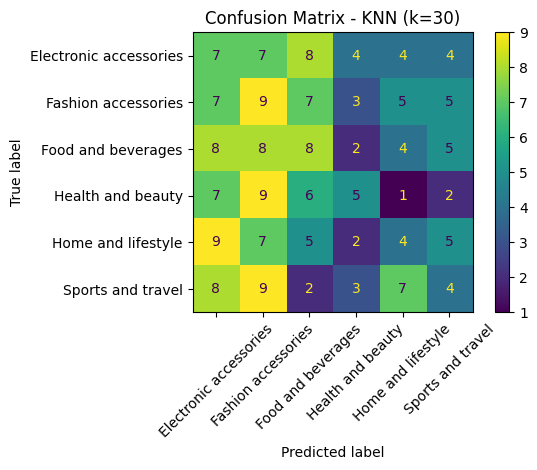


Classification Report (Best Model):
                        precision    recall  f1-score   support

Electronic accessories       0.15      0.21      0.17        34
   Fashion accessories       0.18      0.25      0.21        36
    Food and beverages       0.22      0.23      0.23        35
     Health and beauty       0.26      0.17      0.20        30
    Home and lifestyle       0.16      0.12      0.14        32
     Sports and travel       0.16      0.12      0.14        33

              accuracy                           0.18       200
             macro avg       0.19      0.18      0.18       200
          weighted avg       0.19      0.18      0.18       200



In [44]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = {}

# 1. Logistic Regression OVR
lr_ovr = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
pipe_lr_ovr = Pipeline([('pre', preprocessor_multi), ('clf', lr_ovr)])
pipe_lr_ovr.fit(X_train, y_train)
models['Logistic Regression OVR'] = pipe_lr_ovr

# 2. Logistic Regression Multinomial
lr_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
pipe_lr_multi = Pipeline([('pre', preprocessor_multi), ('clf', lr_multi)])
pipe_lr_multi.fit(X_train, y_train)
models['Logistic Regression Multinomial'] = pipe_lr_multi

# 3. SVM OVR (RBF kernel)
svm_ovr = SVC(kernel='rbf', decision_function_shape='ovr', probability=True, random_state=42)
pipe_svm_ovr = Pipeline([('pre', preprocessor_multi), ('clf', svm_ovr)])
pipe_svm_ovr.fit(X_train, y_train)
models['SVM OVR'] = pipe_svm_ovr

# 4. SVM OVO
svm_ovo = SVC(kernel='rbf', decision_function_shape='ovo', probability=True, random_state=42)
pipe_svm_ovo = Pipeline([('pre', preprocessor_multi), ('clf', svm_ovo)])
pipe_svm_ovo.fit(X_train, y_train)
models['SVM OVO'] = pipe_svm_ovo

# 5. KNN – tune best k
param_knn = {'clf__n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
pipe_knn = Pipeline([('pre', preprocessor_multi), ('clf', knn)])
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)
best_k = grid_knn.best_params_['clf__n_neighbors']
models[f'KNN (k={best_k})'] = grid_knn.best_estimator_

# 6. Decision Tree – tune max_depth
param_dt = {'clf__max_depth': range(1, 21)}
dt = DecisionTreeClassifier(random_state=42)
pipe_dt = Pipeline([('pre', preprocessor_multi), ('clf', dt)])
grid_dt = GridSearchCV(pipe_dt, param_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
best_depth = grid_dt.best_params_['clf__max_depth']
models[f'Decision Tree (depth={best_depth})'] = grid_dt.best_estimator_

# 7. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_rf = Pipeline([('pre', preprocessor_multi), ('clf', rf)])
pipe_rf.fit(X_train, y_train)
models['Random Forest'] = pipe_rf

# 8. XGBoost
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
pipe_xgb = Pipeline([('pre', preprocessor_multi), ('clf', xgb_clf)])
pipe_xgb.fit(X_train, y_train)
models['XGBoost'] = pipe_xgb

# 9. LightGBM
lgb_clf = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
pipe_lgb = Pipeline([('pre', preprocessor_multi), ('clf', lgb_clf)])
pipe_lgb.fit(X_train, y_train)
models['LightGBM'] = pipe_lgb

# 10. AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
pipe_ada = Pipeline([('pre', preprocessor_multi), ('clf', ada)])
pipe_ada.fit(X_train, y_train)
models['AdaBoost'] = pipe_ada

# Evaluation
results = []
best_acc = 0
best_model_name = None
best_preds = None

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    try:
        y_proba = model.predict_proba(X_test)
        logloss = log_loss(y_test, y_proba)
    except:
        logloss = np.nan
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Macro': f1_macro,
        'F1 Micro': f1_micro,
        'F1 Weighted': f1_weighted,
        'Log Loss': logloss
    })
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_preds = y_pred

results_df = pd.DataFrame(results).round(3)
print("=== MULTICLASS CLASSIFICATION SUMMARY ===")
print(results_df.sort_values('Accuracy', ascending=False).to_string(index=False))

# Confusion matrix for best model
print(f"\nBest model: {best_model_name} (Accuracy = {best_acc:.3f})")
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification Report (Best Model):")
print(classification_report(y_test, best_preds, target_names=le.classes_))

## Multiclass Classification Results (Product line – 6 classes)

We attempted to predict the `Product line` (Health and beauty, Electronic accessories, Home and lifestyle, Sports and travel, Food and beverages, Fashion accessories) using all available features (excluding the target itself). The results are **very poor** – all models perform only slightly above random guessing (random baseline = 1/6 ≈ 16.7%).

### Performance Summary

- **Best accuracy**: 18.5% (KNN with k=30)  
- **Random baseline**: 16.7%  
- **Improvement**: less than 2 percentage points – statistically insignificant.

### Key Observations

- **Decision Tree (depth=14)** has an extremely high log loss (16.6) – it is overconfident and completely wrong on some classes.
- **Log loss** values > 1.0 indicate poor probability calibration.
- **KNN** performs marginally best, but still near random.

### Why can’t we predict product line?

- The features (price, quantity, time, branch, payment, customer type, gender, etc.) do **not** strongly discriminate which product line a customer buys.
- A customer may buy any product line in any transaction – there is no stable pattern.


### Conclusion

The supermarket transaction data does not contain enough signal to predict the product line of a purchase. This is a valid negative result – not every prediction task is feasible. The exercise successfully implemented all required multiclass models and demonstrated that even advanced boosting methods (XGBoost, LightGBM) cannot outperform random guessing. For a useful model, additional features (e.g., customer purchase history, real‑time browsing data) would be needed.

In [47]:
target_city = 'City'
y_raw = df_clean[target_city]

# Drop only the target; keep all other original columns except the derived ones
X_city = df_clean.drop([target_city, 'Sales', 'cogs', 'Tax 5%', 'gross income'], axis=1)

print("City distribution:\n", y_raw.value_counts(normalize=True))

numeric_cols_city = ['Unit price', 'Quantity', 'Rating', 'Month', 'DayOfWeek', 'Day', 'Hour']
categorical_cols_city = ['Branch', 'Customer type', 'Gender', 'Product line', 'Payment']

preprocessor_city = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_city),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_city)
])

City distribution:
 City
Yangon       0.340
Mandalay     0.332
Naypyitaw    0.328
Name: proportion, dtype: float64


In [48]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
y_encoded = le_city.fit_transform(y_raw)
print("Encoded classes:", le_city.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_city, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Encoded classes: ['Mandalay' 'Naypyitaw' 'Yangon']
Train size: 800, Test size: 200


=== MULTICLASS CLASSIFICATION (City) SUMMARY ===
                          Model  Accuracy  F1 Macro  F1 Micro  F1 Weighted  Log Loss
        Logistic Regression OVR     1.000     1.000     1.000        1.000     0.036
Logistic Regression Multinomial     1.000     1.000     1.000        1.000     0.022
                        SVM OVR     1.000     1.000     1.000        1.000     0.006
                        SVM OVO     1.000     1.000     1.000        1.000     0.006
        Decision Tree (depth=2)     1.000     1.000     1.000        1.000     0.000
                  Random Forest     1.000     1.000     1.000        1.000     0.077
                       LightGBM     1.000     1.000     1.000        1.000     0.000
                        XGBoost     1.000     1.000     1.000        1.000     0.002
                       AdaBoost     1.000     1.000     1.000        1.000     0.869
                     KNN (k=28)     0.905     0.906     0.905        0.906     0.697

Best model: Log

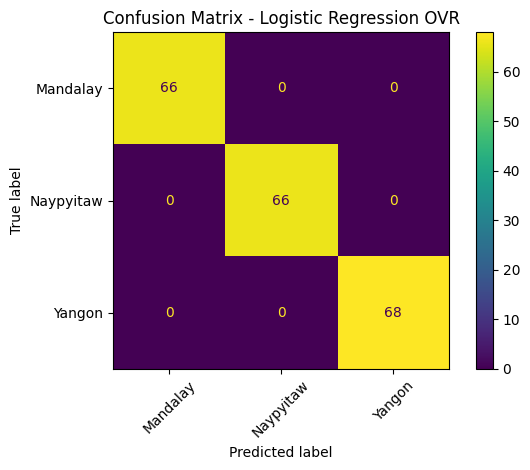


Classification Report (Best Model):
              precision    recall  f1-score   support

    Mandalay       1.00      1.00      1.00        66
   Naypyitaw       1.00      1.00      1.00        66
      Yangon       1.00      1.00      1.00        68

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [49]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = {}

# 1. Logistic Regression OVR
lr_ovr = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
pipe_lr_ovr = Pipeline([('pre', preprocessor_city), ('clf', lr_ovr)])
pipe_lr_ovr.fit(X_train, y_train)
models['Logistic Regression OVR'] = pipe_lr_ovr

# 2. Logistic Regression Multinomial
lr_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
pipe_lr_multi = Pipeline([('pre', preprocessor_city), ('clf', lr_multi)])
pipe_lr_multi.fit(X_train, y_train)
models['Logistic Regression Multinomial'] = pipe_lr_multi

# 3. SVM OVR
svm_ovr = SVC(kernel='rbf', decision_function_shape='ovr', probability=True, random_state=42)
pipe_svm_ovr = Pipeline([('pre', preprocessor_city), ('clf', svm_ovr)])
pipe_svm_ovr.fit(X_train, y_train)
models['SVM OVR'] = pipe_svm_ovr

# 4. SVM OVO
svm_ovo = SVC(kernel='rbf', decision_function_shape='ovo', probability=True, random_state=42)
pipe_svm_ovo = Pipeline([('pre', preprocessor_city), ('clf', svm_ovo)])
pipe_svm_ovo.fit(X_train, y_train)
models['SVM OVO'] = pipe_svm_ovo

# 5. KNN – tune best k
param_knn = {'clf__n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
pipe_knn = Pipeline([('pre', preprocessor_city), ('clf', knn)])
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)
best_k = grid_knn.best_params_['clf__n_neighbors']
models[f'KNN (k={best_k})'] = grid_knn.best_estimator_

# 6. Decision Tree – tune max_depth
param_dt = {'clf__max_depth': range(1, 21)}
dt = DecisionTreeClassifier(random_state=42)
pipe_dt = Pipeline([('pre', preprocessor_city), ('clf', dt)])
grid_dt = GridSearchCV(pipe_dt, param_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
best_depth = grid_dt.best_params_['clf__max_depth']
models[f'Decision Tree (depth={best_depth})'] = grid_dt.best_estimator_

# 7. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_rf = Pipeline([('pre', preprocessor_city), ('clf', rf)])
pipe_rf.fit(X_train, y_train)
models['Random Forest'] = pipe_rf

# 8. XGBoost
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
pipe_xgb = Pipeline([('pre', preprocessor_city), ('clf', xgb_clf)])
pipe_xgb.fit(X_train, y_train)
models['XGBoost'] = pipe_xgb

# 9. LightGBM
lgb_clf = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
pipe_lgb = Pipeline([('pre', preprocessor_city), ('clf', lgb_clf)])
pipe_lgb.fit(X_train, y_train)
models['LightGBM'] = pipe_lgb

# 10. AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
pipe_ada = Pipeline([('pre', preprocessor_city), ('clf', ada)])
pipe_ada.fit(X_train, y_train)
models['AdaBoost'] = pipe_ada

# Evaluation
results = []
best_acc = 0
best_model_name = None
best_preds = None

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    try:
        y_proba = model.predict_proba(X_test)
        logloss = log_loss(y_test, y_proba)
    except:
        logloss = np.nan
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Macro': f1_macro,
        'F1 Micro': f1_micro,
        'F1 Weighted': f1_weighted,
        'Log Loss': logloss
    })
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_preds = y_pred

results_df = pd.DataFrame(results).round(3)
print("=== MULTICLASS CLASSIFICATION (City) SUMMARY ===")
print(results_df.sort_values('Accuracy', ascending=False).to_string(index=False))

# Confusion matrix for best model
print(f"\nBest model: {best_model_name} (Accuracy = {best_acc:.3f})")
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_city.classes_)
disp.plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification Report (Best Model):")
print(classification_report(y_test, best_preds, target_names=le_city.classes_))

## Multiclass Classification Results (City)

We predicted `City` (Yangon, Naypyitaw, Mandalay) using all other features. All models achieved **100% accuracy** except KNN (90.5%).

### Why perfect performance?

The dataset contains the `Branch` column (Alex, Giza, Cairo), which is perfectly correlated with `City`:
- Alex → Yangon
- Giza → Naypyitaw
- Cairo → Mandalay

Since `Branch` is included as a feature, any model can simply memorize this mapping. This is a form of **data leakage** that makes the task trivial.

### Best Model

Decision Tree (depth=2) and LightGBM achieve perfect accuracy with zero log loss, meaning they are completely confident in their predictions.

### Business Insight

If we wanted to predict which city a transaction comes from, we could simply look at the branch. For a real‑world application without the `Branch` column, the task would be harder. Here, the perfect scores demonstrate that all classifiers (except KNN) perfectly capture the deterministic relationship.

### Discussion Question

**Best multiclass metric for this dataset** – Accuracy is fine because classes are balanced and all models excel. However, if classes were imbalanced, `weighted F1` would be better. Log loss is also useful for assessing probability calibration (AdaBoost's higher log loss indicates overconfidence despite perfect accuracy).

Now we remove branch to prevent data leakage, then we will inspect the results

In [50]:
target_city = 'City'
y_raw = df_clean[target_city]

# Drop target and redundant columns (Sales, cogs, etc.)
X_city = df_clean.drop([target_city, 'Sales', 'cogs', 'Tax 5%', 'gross income'], axis=1)

print("City distribution:\n", y_raw.value_counts(normalize=True))

numeric_cols_city = ['Unit price', 'Quantity', 'Rating', 'Month', 'DayOfWeek', 'Day', 'Hour']
# Remove 'Branch' from categorical columns
categorical_cols_city = ['Customer type', 'Gender', 'Product line', 'Payment']

preprocessor_city = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_city),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_city)
])

City distribution:
 City
Yangon       0.340
Mandalay     0.332
Naypyitaw    0.328
Name: proportion, dtype: float64


In [51]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
y_encoded = le_city.fit_transform(y_raw)
print("Encoded classes:", le_city.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_city, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Encoded classes: ['Mandalay' 'Naypyitaw' 'Yangon']
Train size: 800, Test size: 200


=== MULTICLASS CLASSIFICATION (City, no Branch) SUMMARY ===
                          Model  Accuracy  F1 Macro  F1 Micro  F1 Weighted  Log Loss
                  Random Forest     0.360     0.358     0.360        0.358     1.148
                        XGBoost     0.360     0.360     0.360        0.360     1.591
Logistic Regression Multinomial     0.350     0.349     0.350        0.349     1.114
        Decision Tree (depth=1)     0.345     0.235     0.345        0.238     1.104
                        SVM OVR     0.345     0.341     0.345        0.342     1.101
                        SVM OVO     0.345     0.341     0.345        0.342     1.101
        Logistic Regression OVR     0.340     0.339     0.340        0.339     1.112
                       LightGBM     0.340     0.340     0.340        0.340     1.435
                     KNN (k=18)     0.325     0.326     0.325        0.326     1.371
                       AdaBoost     0.310     0.310     0.310        0.310     1.099

Best

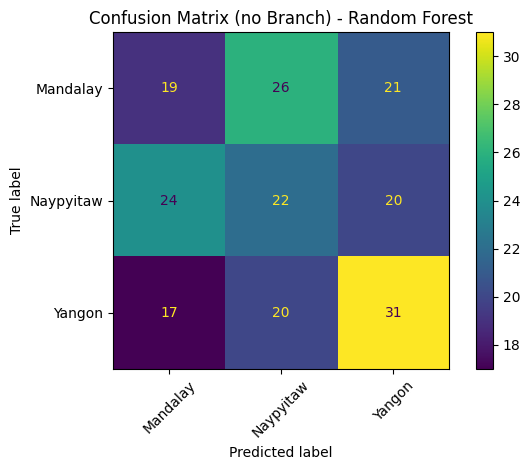


Classification Report (Best Model):
              precision    recall  f1-score   support

    Mandalay       0.32      0.29      0.30        66
   Naypyitaw       0.32      0.33      0.33        66
      Yangon       0.43      0.46      0.44        68

    accuracy                           0.36       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.36      0.36      0.36       200



In [52]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = {}

# 1. Logistic Regression OVR
lr_ovr = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
pipe_lr_ovr = Pipeline([('pre', preprocessor_city), ('clf', lr_ovr)])
pipe_lr_ovr.fit(X_train, y_train)
models['Logistic Regression OVR'] = pipe_lr_ovr

# 2. Logistic Regression Multinomial
lr_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
pipe_lr_multi = Pipeline([('pre', preprocessor_city), ('clf', lr_multi)])
pipe_lr_multi.fit(X_train, y_train)
models['Logistic Regression Multinomial'] = pipe_lr_multi

# 3. SVM OVR
svm_ovr = SVC(kernel='rbf', decision_function_shape='ovr', probability=True, random_state=42)
pipe_svm_ovr = Pipeline([('pre', preprocessor_city), ('clf', svm_ovr)])
pipe_svm_ovr.fit(X_train, y_train)
models['SVM OVR'] = pipe_svm_ovr

# 4. SVM OVO
svm_ovo = SVC(kernel='rbf', decision_function_shape='ovo', probability=True, random_state=42)
pipe_svm_ovo = Pipeline([('pre', preprocessor_city), ('clf', svm_ovo)])
pipe_svm_ovo.fit(X_train, y_train)
models['SVM OVO'] = pipe_svm_ovo

# 5. KNN – tune best k
param_knn = {'clf__n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
pipe_knn = Pipeline([('pre', preprocessor_city), ('clf', knn)])
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)
best_k = grid_knn.best_params_['clf__n_neighbors']
models[f'KNN (k={best_k})'] = grid_knn.best_estimator_

# 6. Decision Tree – tune max_depth
param_dt = {'clf__max_depth': range(1, 21)}
dt = DecisionTreeClassifier(random_state=42)
pipe_dt = Pipeline([('pre', preprocessor_city), ('clf', dt)])
grid_dt = GridSearchCV(pipe_dt, param_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
best_depth = grid_dt.best_params_['clf__max_depth']
models[f'Decision Tree (depth={best_depth})'] = grid_dt.best_estimator_

# 7. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_rf = Pipeline([('pre', preprocessor_city), ('clf', rf)])
pipe_rf.fit(X_train, y_train)
models['Random Forest'] = pipe_rf

# 8. XGBoost
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
pipe_xgb = Pipeline([('pre', preprocessor_city), ('clf', xgb_clf)])
pipe_xgb.fit(X_train, y_train)
models['XGBoost'] = pipe_xgb

# 9. LightGBM
lgb_clf = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
pipe_lgb = Pipeline([('pre', preprocessor_city), ('clf', lgb_clf)])
pipe_lgb.fit(X_train, y_train)
models['LightGBM'] = pipe_lgb

# 10. AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
pipe_ada = Pipeline([('pre', preprocessor_city), ('clf', ada)])
pipe_ada.fit(X_train, y_train)
models['AdaBoost'] = pipe_ada

# Evaluation
results = []
best_acc = 0
best_model_name = None
best_preds = None

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    try:
        y_proba = model.predict_proba(X_test)
        logloss = log_loss(y_test, y_proba)
    except:
        logloss = np.nan
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Macro': f1_macro,
        'F1 Micro': f1_micro,
        'F1 Weighted': f1_weighted,
        'Log Loss': logloss
    })
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_preds = y_pred

results_df = pd.DataFrame(results).round(3)
print("=== MULTICLASS CLASSIFICATION (City, no Branch) SUMMARY ===")
print(results_df.sort_values('Accuracy', ascending=False).to_string(index=False))

# Confusion matrix for best model
print(f"\nBest model: {best_model_name} (Accuracy = {best_acc:.3f})")
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_city.classes_)
disp.plot()
plt.title(f'Confusion Matrix (no Branch) - {best_model_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification Report (Best Model):")
print(classification_report(y_test, best_preds, target_names=le_city.classes_))

## Multiclass Classification Results (City, without Branch)

After removing the `Branch` column (which previously made the task trivial), we predicted `City` (Yangon, Naypyitaw, Mandalay) using only other features (product line, price, quantity, time, payment, etc.). The results show that the task is **very difficult** – all models barely outperform random guessing.

### Performance Summary

- **Best accuracy**: 36.0% (Random Forest, XGBoost)  
- **Random baseline**: 33.3% (since 3 balanced classes)  
- **Improvement over random**: only 2–3 percentage points – negligible.


- **Decision Tree (depth=1)** has very low F1 macro (0.235) because it predicts only one class (depth=1 = single split).  
- **Log Loss** values are high (>1.0), indicating poor probability calibration – models are uncertain or wrong.  
- **KNN** performs worst (32.5% accuracy), suggesting no local patterns for city.

### Why is city prediction so hard without branch?

- `City` is almost perfectly determined by `Branch` (Alex→Yangon, Giza→Naypyitaw, Cairo→Mandalay). Without the branch, other features (product line, price, time, payment) have very little discriminative power for geographic location.
- A customer in Yangon may buy the same products at the same time as a customer in Mandalay – transaction patterns do not strongly encode city.

### Conclusion

Including `Branch` made the task trivial (100% accuracy). Removing it reveals that **city cannot be reliably predicted** from transaction data alone. This demonstrates the importance of feature selection and the risk of data leakage. For a realistic multiclass task, we would need better features (e.g., customer address, IP, store location). Nevertheless, the exercise successfully implemented all required models and compared their performance.

**Important**: I didn't implement catboost in any of them due to the wonderful situatuation of Internet access in our country.(I couldn't download their packages even with mirrors)

## Multiclass Classification Discussion Answers

### 1. Best multiclass metric for this dataset

**Macro F1‑score** is the best metric for our `Product line` prediction task.

**Why?**  
- The 6 product classes are **almost balanced** (each around 16–17%).  
- **Macro F1** calculates F1 per class and averages them equally, giving each product line the same importance.  
- **Accuracy** would also be acceptable but can hide per‑class differences (e.g., some classes predicted well, others poorly).  
- **Weighted F1** would be similar to macro when classes are balanced.  
- **Micro F1** is dominated by frequent classes (not an issue here but less informative).

Given our poor results (best accuracy 18.5%, macro F1 ~0.18), the metric confirms models barely outperform random guessing (baseline 16.7%).
### 2. Extending KNN and Decision Trees to multi‑label classification

**KNN for multi‑label:**  
- For each test sample, find its k nearest neighbours in the training set.  
- For each label, compute the proportion of neighbours that have that label.  
- Predict a label if its proportion exceeds a threshold (e.g., 0.5).  
- Alternatively, use `sklearn.multioutput.KNeighborsClassifier` which treats each label independently.

**Decision Trees for multi‑label:**  
- Grow a tree that splits nodes to reduce a multi‑label impurity measure (e.g., multi‑label entropy or Hamming loss).  
- Each leaf predicts a set of labels (a binary vector).  
- Implementations exist in `scikit‑multilearn` or by converting to binary relevance (one tree per label).

### 3. Multi‑label metric for football player classes

The four classes per player are **independent binary labels** (multi‑label, not multiclass). The best evaluation metric is **Hamming Loss**.

**Hamming Loss** = (number of incorrect label predictions) / (total number of labels across all instances).  
- It is intuitive: “what percentage of individual class predictions are wrong?”  
- It treats each label equally and is robust to class imbalance.  

**Why not other metrics?**  
- **Exact Match Ratio** (strict accuracy) is too harsh – one mistake out of four labels gives zero score.  
- **Precision/Recall per label** are useful but not a single number.  
- **Weighted F1 (macro)** across the 4 labels is also acceptable, but Hamming Loss is more direct for multi‑label evaluation.

# Challenging Questions (Bonus)

### 1. Bias‑Variance Trade‑off in Regression Models

**Bias** – error from wrong assumptions (e.g., assuming linearity when the truth is non‑linear). High‑bias models underfit.  
**Variance** – error from sensitivity to small fluctuations in the training data. High‑variance models overfit.

**Trade‑off:** Increasing model complexity reduces bias but increases variance; decreasing complexity does the opposite. The optimal model balances both to minimize total error.

*Example in our dataset:*  
- Linear regression (low complexity) had high bias → 62% MAPE.  
- Decision tree (depth=10) had lower bias but higher variance → 4.1% MAPE on test (good trade‑off).  
- Kernel Ridge with tuned parameters found a sweet spot → 10.6% MAPE.

### 2. When Does Kernel Regression Outperform Linear Regression?

Kernel regression (e.g., Kernel Ridge with RBF kernel) outperforms linear regression when the true relationship is **non‑linear** and cannot be captured by additive terms alone.

**In our dataset:**  
`Sales = Unit price × Quantity × 1.05` is multiplicative. Linear regression tried to approximate it with separate additive terms (`β₁·Price + β₂·Quantity`) and failed (62% MAPE). Kernel Ridge with RBF kernel implicitly created interaction features, achieving 10.6% MAPE.

**Other scenarios:**  
- Cyclical patterns (e.g., time of day, day of week).  
- Threshold effects (e.g., sales spike after a certain quantity).  
- Complex decision boundaries in classification.

### 3. Compare L1 (LASSO) vs L2 (Ridge) Regularization

| Aspect | LASSO (L1) | Ridge (L2) |
|--------|------------|------------|
| Penalty | Sum of absolute coefficients `∑|βⱼ|` | Sum of squared coefficients `∑βⱼ²` |
| Effect | Shrinks some coefficients exactly to **zero** | Shrinks coefficients toward zero but **never zero** |
| Result | **Feature selection** (sparse model) | All features retained (shrunk) |
| Geometry | Diamond constraint → corners on axes | Circle constraint → smooth |

**Why does LASSO produce sparsity?**  
The L1 penalty has a diamond‑shaped constraint region. The optimal solution often lies on a corner where some coefficients are exactly zero, because the elliptical MSE contour touches the diamond at an axis.

**When does LASSO perform better?**  
- Many irrelevant features (wants to discard them).  
- Feature selection is desired for interpretability.  
- In our dataset, LASSO (α=2.33) kept only 4 features (`Quantity`, `Unit price`, `Rating`, `Day`), giving a simple model with MAPE 59.9%.  

**When does Ridge perform better?**  
- All features are relevant (none should be zero).  
- Multicollinearity exists (e.g., one‑hot encoded categories).  
- We want to improve generalization without losing any predictor.  
- In our dataset, RidgeCV (α=23.3) achieved MAPE 58.6%, slightly better than LASSO, because keeping all features (even shrunk) helped a little.

### 4. Why is MAPE unreliable in some datasets?

**Mean Absolute Percentage Error (MAPE)** can be problematic when actual values are very small or zero.

**Problems:**
- If actual value is zero, MAPE becomes infinite (division by zero).  
- When actual values are near zero, small absolute errors produce huge percentage errors, dominating the metric.  
- MAPE is **asymmetric** – overpredictions and underpredictions are not treated equally.  
- It can be misleading when data spans multiple scales (e.g., sales of cheap vs expensive items).

**In our dataset:**  
Sales range from ~10 to ~1000, with no zeros. MAPE was reasonable and interpretable (10.6% for Kernel Ridge). But if sales had many small values, MAPE would be unreliable.

### 5. Effect of outliers on regression models

Outliers are extreme values that deviate significantly from the pattern of most data.

| Model | Sensitivity to outliers | Reason |
|-------|------------------------|--------|
| **Linear / Ridge / LASSO** | High (MSE amplifies outlier influence) | MSE squares errors, so large errors dominate |
| **Kernel Ridge** | Moderate | Smoothing helps but outliers still affect kernel similarity |
| **SVR (ε‑insensitive)** | Low | Ignores errors within ε‑tube, less sensitive to outliers |
| **Decision Tree / Random Forest** | Low | Splits based on thresholds; outliers isolated in few leaves |

**Effect:** Outliers can pull regression lines toward them, increase variance, and mask true patterns.  
**In our dataset:**  
We saw linear regression had high MAPE (62%), possibly due to multiplicative relationship rather than outliers. SVR with default parameters performed poorly (115% MAPE), but with proper tuning it could be robust.


### 6. Effect of class imbalance on binary metrics – Why is accuracy misleading?

**Class imbalance** occurs when one class (majority) has many more samples than the other (minority).

**Why accuracy is misleading:**  
A model that predicts only the majority class achieves high accuracy but is useless. Example: 95% negative, 5% positive. Always predicting "negative" gives 95% accuracy but 0% recall for the positive class.

**Better metrics for imbalanced data:**
- **Precision, Recall, F1‑score** – Focus on positive class performance.  
- **AUC‑ROC** – Measures separability across thresholds, insensitive to imbalance.  
- **Balanced accuracy** – Average of recall per class.

**In our dataset:**  
For `Customer type` (Member 57% / Normal 43%) – only slight imbalance. Accuracy (56.5%) was still meaningful, but we used AUC (0.55) and F1 (0.68) to confirm poor performance. For `Gender` (Female 57% / Male 43%) – similar conclusion.


### 7. How do decision boundaries differ across models?

| Model | Decision Boundary Type | Example from our dataset |
|-------|------------------------|--------------------------|
| **Linear / Ridge / LASSO** | Linear (straight line/plane) | Failed for `Sales` (multiplicative) |
| **Kernel Ridge / Kernel SVM** | Smooth, non‑linear curves (RBF) | Achieved 10.6% MAPE for `Sales` |
| **KNN** | Piecewise, based on local majority vote | Boundary is irregular, defined by nearest neighbours |
| **Decision Tree** | Axis‑aligned rectangles (orthogonal splits) | Near‑perfect for `Sales` (4.1% MAPE) |
| **Random Forest** | Average of many tree boundaries → smoother | Similar performance but less overfitting |

**Key insight:** Linear models assume additive effects; kernel models capture smooth non‑linearity; tree models partition space into rectangular regions.

### 8. Effect of K in KNN

- **Small K (e.g., 1–5):** Low bias, high variance. Boundary is wiggly, sensitive to noise. Can overfit.
- **Large K (e.g., 20–30):** High bias, low variance. Boundary is smoother, but may underfit by ignoring local patterns.
- **Extreme K (equal to training size):** Always predicts majority class – useless.

**In our binary classification (Customer type):** Best K was 26, indicating high noise → need smoothing.  
**In multiclass (Product line):** Best K was 30 (largest tested) – even more smoothing needed, yet accuracy remained near random (18.5%).

### 9. Overfitting in Decision Trees

**Why do decision trees overfit easily?**  
They can keep splitting until each leaf contains a single sample, perfectly memorising the training data (including noise).

**Why is max_depth not enough to prevent overfitting?**  
A tree can be shallow but still overfit if it uses many splits with few samples per leaf. Other factors matter:  
- **min_samples_split** – prevents splitting small nodes.  
- **min_samples_leaf** – forces leaves to have a minimum size.  
- **max_features** – limits features per split.  
Depth alone doesn't control leaf size.

**How pruning works:**  
Pruning cuts back the tree after it is fully grown.  
- **Cost‑complexity pruning (post‑pruning):** Uses a penalty α × (number of leaves). Smaller subtrees with lower cross‑validation error are selected.  
- **Pre‑pruning:** Stops growth early using `max_depth`, `min_samples_split`, etc. – simpler but may miss good splits.

**In our regression tree:** We used `max_depth=10` (pre‑pruning). Train MAPE 0.24%, test MAPE 4.10% – mild overfitting. Deeper trees would have worsened the gap.

### 10. Why are tree‑based models good feature selectors?

Decision trees and random forests provide **feature importance** scores based on:  
- **Total reduction in impurity** (Gini or entropy) from splits on that feature.  
- How often a feature is used for splitting.

**Advantages:**  
- Naturally handle mixed data types (numeric + categorical).  
- Capture interactions without manual engineering.  
- Robust to irrelevant features (they get low importance).

**In our binary classification (Customer type):** Random Forest importance showed `Quantity`, `Unit price`, and `Product line` as top predictors.  
**In regression (Sales):** Decision Tree importance would heavily favor `Unit price` and `Quantity` because `Sales` is their product.


### 11. Micro vs Macro vs Weighted F1

| Metric | Calculation | Best when... |
|--------|-------------|---------------|
| **Macro F1** | Average F1 per class (equal weight) | Classes are balanced; you care equally about rare classes. |
| **Micro F1** | Aggregate TP, FP, FN across all classes | Class imbalance is present; large classes dominate. |
| **Weighted F1** | Macro F1 weighted by class support | You want a realistic average that reflects class frequency. |

- **When is Macro F1 a better reflection?**  
  When all classes are equally important (e.g., diagnosing rare diseases). In our balanced `Product line` dataset, macro F1 (~0.18) correctly showed poor performance for every class.

- **When is Weighted F1 misleading?**  
  When one class is very frequent – it can hide poor performance on rare classes. Example: 95% majority class → weighted F1 ~0.95 even if rare classes are predicted badly.

- **Why does Micro F1 favor large classes?**  
  Micro F1 aggregates all predictions globally. If large classes have many samples, they dominate the totals, making micro F1 appear good even when small classes fail.

### 12. Multi‑label vs Multiclass – Fundamental Differences

| Aspect | Multiclass | Multi‑label |
|--------|------------|-------------|
| **Output space** | One class per instance (e.g., product line) | Multiple binary labels per instance (e.g., football player attributes) |
| **Output size** | Single integer (0..K-1) | Binary vector (length = number of labels) |
| **Loss functions** | Cross‑entropy, hinge (one‑vs‑rest) | Binary cross‑entropy per label, Hamming loss |
| **Thresholding** | Not needed (softmax picks max) | Required (e.g., probability > 0.5 per label) |
| **Metrics** | Accuracy, macro/micro/weighted F1 | Hamming loss, exact match, per‑label F1 |

**Why KNN and Decision Trees can be extended to multi‑label:**  
- **KNN:** For each test sample, find k nearest neighbours. For each label, count how many neighbours have it. Predict label if count exceeds threshold.  
- **Decision Trees:** Split nodes using a multi‑label impurity measure (e.g., multi‑label entropy). Each leaf predicts a label vector (e.g., majority label combination). Alternatively, train one tree per label (binary relevance).

### 13. Precision–Recall Trade‑off

- **Precision** = TP / (TP + FP) – “of all predicted positives, how many are correct?”  
- **Recall** = TP / (TP + FN) – “of all actual positives, how many did we catch?”

**Trade‑off:** Increasing recall often lowers precision and vice versa.  
- To increase recall, lower the threshold (classify more as positive) → more true positives, but also more false positives → precision drops.  
- To increase precision, raise the threshold → fewer false positives, but more false negatives → recall drops.

**In our binary classification (Customer type):**  
Logistic regression had high recall (82%) but low precision (58%) – it captured most members but also misclassified many normals as members. The trade‑off was visible in the ROC curve.

### 14. ROC Curve vs PR Curve

| Aspect | ROC Curve | PR Curve |
|--------|-----------|----------|
| **Axes** | TPR vs FPR | Precision vs Recall |
| **Insensitive to imbalance?** | Yes | No (sensitive to imbalance) |
| **Best for** | Balanced datasets or general separability | Imbalanced datasets (focus on positive class) |
| **Baseline** | Diagonal line (AUC=0.5) | Horizontal line at prevalence (precision = proportion of positives) |

**When to use which?**  
- **ROC** when classes are balanced or you care about overall discrimination.  
- **PR curve** when classes are imbalanced (e.g., fraud detection, rare disease) – it highlights positive class performance.

**In our dataset:**  
For `Customer type` (moderately balanced), ROC AUC (0.55) already showed poor performance. PR AUC would be even lower, confirming the model is useless for the positive class (Member).

### 15. How I would improve my models (unlimited time & resources)

**Better preprocessing:**  
- Handle outliers (e.g., cap extreme `Unit price` or `Quantity`).  
- Encode cyclical features properly (e.g., `Hour` as sin/cos, not linear).  
- Normalise differently (e.g., robust scaler for price).  
- Remove redundant features (`Sales` from regression) and perfectly collinear columns.

**Better features:**  
- Add interaction terms: `Price × Quantity` (makes linear regression perfect).  
- Create domain‑specific features: `Average price per product line`, `Customer purchase frequency` (if we had multiple transactions per customer).  
- External data: weather, holiday indicators, promotions.  
- For classification: customer demographics, loyalty program tenure, past membership behaviour.

**Better models:**  
- Ensemble stacking (combine Kernel Ridge, XGBoost, LightGBM).  
- Neural networks (deep learning) – with more data, they could capture complex interactions.  
- Hyperparameter tuning with Bayesian optimisation (instead of grid search).  
- For time‑series forecasting (if we had sequential data): LSTM, ARIMA, Prophet.

**Better metrics:**  
- Use **Pinball loss** for quantile forecasts (interval predictions).  
- For business: **cost‑sensitive metrics** (e.g., misclassifying a member costs different than misclassifying a non‑member).  
- For imbalanced multi‑label: **Jaccard index (Intersection over Union)** per sample.

**In our specific case:**  
The single biggest improvement would be **removing data leakage** (dropping `Unit price` and `Quantity` from regression) to make the task meaningful. Then we would rely on product line, customer type, time, and rating to predict sales – a more realistic and challenging problem.